# 03. Оценка дальности, TDOA-триангуляция и покрытие (v5)

**Изменения v4 -> v5:**

1. **Fix 0.1:** GCC-PHAT — убран `abs()` в argmax (выбирал anti-correlation пики)
2. **Fix 0.2:** Bandpass regression fix — adaptive 1000-3000 Hz (было 500-4000 — регрессия!)
3. **Fix 0.3:** `amplitude_localize()` — использует реальный measured SNR
4. **3.1:** Subpixel interpolation (квадратичная) — точность ±21мм вместо ±31мм
5. **3.2:** PHAT-beta=0.75 — мягкое отбеливание для лесной реверберации
6. **3.3:** Median GCC accumulation (30 фреймов) — для непрерывных звуков
7. **3.4:** MAD outlier rejection — робастная оценка без multipath выбросов
8. **3.5:** Early-peak selection — прямой путь вместо самого большого пика
9. **3.6:** DEMON для engine — демодуляция узкополосного сигнала
10. **3.7:** Spectral subtraction — подавление стационарного дождя перед GCC

**Методы TDOA по типу сигнала:**
- `gunshot`: стандартный GCC-PHAT + subpixel (импульсный, wideband)
- `chainsaw`: median GCC + bandpass 1000-3000 Hz + PHAT-beta=0.75 + spectral subtraction
- `engine`: DEMON (envelope demodulation) + GCC-PHAT

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import tensorflow_hub as hub
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal as scipy_signal
from scipy.optimize import least_squares
from pathlib import Path

ROOT = Path('../data')
TARGETS_DIR = ROOT / 'targets'
BG_DIR = ROOT / 'backgrounds'
RESULTS_DIR = Path('../results')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

TARGET_SR = 16000
SPEED_OF_SOUND = 343.0  # м/с
ALL_TARGETS = ['chainsaw', 'gunshot', 'engine', 'axe', 'fire']

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

/Users/user/personal/notes/Obsidian/obsidian_main/projects/yandex_casechemp/audio_poc/.venv/lib/python3.12/site-packages/tensorflow_hub/__init__.py:61: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


## Загрузка YAMNet и маппинг классов

In [2]:
print('Загружаем YAMNet...')
model = hub.load('https://tfhub.dev/google/yamnet/1')

class_map_path = model.class_map_path().numpy().decode('utf-8')
class_map_df = pd.read_csv(class_map_path)

class_name_to_idx = {}
for _, row in class_map_df.iterrows():
    class_name_to_idx[row['display_name']] = row['index']

def find_idx(names):
    return [class_name_to_idx[n] for n in names if n in class_name_to_idx]

TARGET_CLASSES = {
    'chainsaw': {
        'primary': ['Chainsaw'],
        'family': ['Chainsaw', 'Power tool', 'Lawn mower', 'Medium engine (mid frequency)',
                   'Vehicle', 'Engine'],
    },
    'gunshot': {
        'primary': ['Gunshot, gunfire'],
        'family': ['Gunshot, gunfire', 'Machine gun', 'Fusillade', 'Firecracker',
                   'Explosion', 'Burst, pop'],
    },
    'engine': {
        'primary': ['Engine'],
        'family': ['Engine', 'Light engine (high frequency)', 'Medium engine (mid frequency)',
                   'Heavy engine (low frequency)', 'Engine starting',
                   'Vehicle', 'Motor vehicle (road)', 'Truck'],
    },
    'axe': {
        'primary': ['Chop'],
        'family': ['Chop', 'Wood', 'Hammer', 'Crack', 'Thump, thud',
                   'Knock', 'Bang'],
    },
    'fire': {
        'primary': ['Fire'],
        'family': ['Fire', 'Crackle', 'Firecracker', 'Fire alarm'],
    },
}

TARGET_INDICES = {}
for t, info in TARGET_CLASSES.items():
    TARGET_INDICES[t] = {
        'primary': find_idx(info['primary']),
        'family': find_idx(info['family']),
    }
    print(f"{t}: primary={TARGET_INDICES[t]['primary']}, family={TARGET_INDICES[t]['family']}")

def run_yamnet(audio):
    waveform = tf.cast(audio, tf.float32)
    scores, _, _ = model(waveform)
    return scores.numpy().mean(axis=0)

def get_top_k(scores, k=5):
    top_idx = np.argsort(scores)[::-1][:k]
    return [(int(i), class_map_df.iloc[i]['display_name'], float(scores[i])) for i in top_idx]

print('Модель загружена.')

Загружаем YAMNet...
chainsaw: primary=[341], family=[341, 418, 340, 342, 294, 337]
gunshot: primary=[421], family=[421, 422, 423, 427, 420, 428]
engine: primary=[337], family=[337, 338, 342, 343, 345, 294, 300, 310]
axe: primary=[432], family=[432, 431, 413, 434, 454, 353, 460]
fire: primary=[292], family=[292, 293, 427, 394]
Модель загружена.


## Секция 1 — SPL-модель распространения звука

**Физика:** SPL_received = SPL_source - 20·log10(d) - α·d

- Spreading loss: 6 дБ на удвоение (закон обратных квадратов)
- Excess attenuation α: 0.03 (редкий лес) — 0.10 (густой лес) дБ/м

Источники: ISO 9613-2, ERDC/CRREL TR-04-18, Hoover 1961

In [3]:
# SPL источников (дБ SPL на 1м)
SOURCE_SPL = {'chainsaw': 110, 'gunshot': 140, 'engine': 95, 'axe': 85, 'fire': 80}

# Фоновый шум (дБ SPL)
NOISE_SPL_MAP = {
    'silence': 25, 'forest_night': 30, 'birds': 45,
    'rain': 55, 'wind': 55, 'river': 60,
}

# Для coverage heatmap (абстрактные уровни)
NOISE_SPL = {'quiet': 30, 'moderate': 45, 'windy': 55}

# SNR threshold
SNR_THRESHOLD = 5  # дБ

# Unified forest attenuation (v3: used everywhere)
DEFAULT_EXCESS_ATTEN = 0.05  # dB/m, typical forest (ISO 9613-2)


def compute_realistic_snr(source_spl, noise_spl, distance_m, excess_atten=DEFAULT_EXCESS_ATTEN):
    """SNR на расстоянии с учётом spreading loss + лесного затухания."""
    if distance_m <= 1.0:
        return source_spl - noise_spl
    spreading_loss = 20 * np.log10(distance_m)
    excess_loss = excess_atten * max(distance_m - 1, 0)
    received_spl = source_spl - spreading_loss - excess_loss
    return received_spl - noise_spl


def mix_with_snr(signal, noise, snr_db):
    """Микширование сигнала с шумом при заданном SNR (копия из NB01 v5).

    v5 Fix: нормализация ДО микширования + soft clipping вместо hard norm.
    """
    if len(noise) < len(signal):
        noise = np.tile(noise, int(np.ceil(len(signal) / len(noise))))
    noise = noise[:len(signal)]

    rms_signal = np.sqrt(np.mean(signal ** 2))
    rms_noise = np.sqrt(np.mean(noise ** 2))

    if rms_noise == 0 or rms_signal == 0:
        return signal.copy()

    # v5: нормализуем signal к unit peak ДО микширования
    sig_peak = np.max(np.abs(signal))
    if sig_peak > 0:
        signal_norm = signal / sig_peak * 0.7  # headroom
    else:
        signal_norm = signal.copy()

    rms_signal_norm = np.sqrt(np.mean(signal_norm ** 2))
    target_rms_noise = rms_signal_norm / (10 ** (snr_db / 20))
    noise_scaled = noise * (target_rms_noise / rms_noise)

    mixed = signal_norm + noise_scaled
    peak = np.max(np.abs(mixed))
    if peak > 1.0:
        mixed = np.tanh(mixed)  # v5: soft clipping
    return mixed


# Верификация: SNR chainsaw при 1м в тишине
snr_check = compute_realistic_snr(110, 25, 1.0)
print(f'Chainsaw SNR при 1м (silence): {snr_check:.0f} дБ (ожидание: ~85)')
snr_check2 = compute_realistic_snr(110, 45, 100.0)
print(f'Chainsaw SNR при 100м (birds, forest): {snr_check2:.1f} дБ')
snr_check3 = compute_realistic_snr(140, 45, 500.0)
print(f'Gunshot SNR при 500м (birds, forest): {snr_check3:.1f} дБ')
print(f'\nDEFAULT_EXCESS_ATTEN = {DEFAULT_EXCESS_ATTEN} dB/m (unified across all sections)')

Chainsaw SNR при 1м (silence): 85 дБ (ожидание: ~85)
Chainsaw SNR при 100м (birds, forest): 20.0 дБ
Gunshot SNR при 500м (birds, forest): 16.1 дБ

DEFAULT_EXCESS_ATTEN = 0.05 dB/m (unified across all sections)


## Секция 2 — Загрузка данных

In [4]:
# Загрузка фонов
bg_names = ['rain', 'wind', 'birds', 'forest_night', 'river', 'silence']
bg_audio = {}
for name in bg_names:
    bg_dir = BG_DIR / name
    if bg_dir.exists():
        files = sorted(bg_dir.glob('*.wav'))
        if files:
            audio, _ = librosa.load(str(files[0]), sr=TARGET_SR)
            bg_audio[name] = audio
            print(f'Background {name}: {len(audio)/TARGET_SR:.1f} сек')

# Загрузка targets (по 3 сэмпла)
N_SAMPLES = 3
target_samples = {}
for name in ALL_TARGETS:
    t_dir = TARGETS_DIR / name
    if not t_dir.exists():
        print(f'WARNING: {t_dir} не найден')
        continue
    wavs = sorted(t_dir.glob('*.wav'))[:N_SAMPLES]
    samples = []
    for f in wavs:
        audio, _ = librosa.load(str(f), sr=TARGET_SR)
        samples.append(audio)
    target_samples[name] = samples
    print(f'Target {name}: {len(samples)} сэмплов')

Background rain: 5.0 сек
Background wind: 5.0 сек
Background birds: 10.0 сек
Background forest_night: 5.0 сек
Background river: 5.0 сек
Background silence: 5.0 сек
Target chainsaw: 3 сэмплов
Target gunshot: 3 сэмплов
Target engine: 3 сэмплов
Target axe: 3 сэмплов
Target fire: 3 сэмплов


## Секция 3 — Оценка дальности (SPL-модель)

Для каждого (target × background × distance): вычисляем SNR из физики, микшируем через `mix_with_snr`, прогоняем YAMNet.

Два режима: free-field (α=0) и forest (α=0.05 дБ/м).

In [5]:
DISTANCES = [1, 5, 10, 25, 50, 100, 200, 500, 1000]

distance_results = []

for target_name, samples in target_samples.items():
    print(f'\nОбработка: {target_name}')
    pi = TARGET_INDICES[target_name]['primary']
    fi = TARGET_INDICES[target_name]['family']
    source_spl = SOURCE_SPL[target_name]

    for bg_name, noise in bg_audio.items():
        noise_spl = NOISE_SPL_MAP.get(bg_name, 45)

        for atten_label, excess in [('free_field', 0.0), ('forest', 0.05)]:
            for distance in DISTANCES:
                snr_db = compute_realistic_snr(source_spl, noise_spl, distance, excess)

                for i, sig in enumerate(samples):
                    mixed = mix_with_snr(sig, noise, snr_db)

                    scores = run_yamnet(mixed)
                    top5 = get_top_k(scores, 5)
                    top5_idx = [t[0] for t in top5]

                    t_score_primary = float(max((scores[idx] for idx in pi), default=0.0))
                    t_score_family = float(max((scores[idx] for idx in fi), default=0.0))

                    distance_results.append({
                        'target_class': target_name,
                        'background': bg_name,
                        'atten_model': atten_label,
                        'distance_m': distance,
                        'sample_idx': i,
                        'snr_db': float(snr_db),
                        'top1_class': top5[0][1],
                        'top1_score': top5[0][2],
                        'target_score_primary': t_score_primary,
                        'target_score_family': t_score_family,
                        'primary_in_top1': top5_idx[0] in pi,
                        'primary_in_top5': any(idx in pi for idx in top5_idx[:5]),
                        'family_in_top5': any(idx in fi for idx in top5_idx[:5]),
                    })

dist_df = pd.DataFrame(distance_results)
dist_df.to_csv(RESULTS_DIR / 'distance_results_v5.csv', index=False)
print(f'\nСохранено: {len(dist_df)} записей -> distance_results_v5.csv')


Обработка: chainsaw

Обработка: gunshot

Обработка: engine

Обработка: axe

Обработка: fire

Сохранено: 1620 записей -> distance_results_v5.csv


In [6]:
# Сводная таблица
for target in ALL_TARGETS:
    if target not in target_samples:
        continue
    print(f'\n=== {target} (source SPL: {SOURCE_SPL[target]} дБ) ===')
    for atten in ['free_field', 'forest']:
        sub = dist_df[(dist_df['target_class'] == target) & (dist_df['atten_model'] == atten)]
        summary = sub.groupby('distance_m').agg({
            'target_score_family': 'mean',
            'snr_db': 'mean',
            'family_in_top5': 'mean',
        }).reset_index()
        summary.columns = ['Distance', 'Family Score', 'SNR dB', 'Family Top-5']
        print(f'\n  {atten}:')
        print(summary.to_string(index=False))


=== chainsaw (source SPL: 110 дБ) ===

  free_field:
 Distance  Family Score  SNR dB  Family Top-5
        1      0.475357 65.0000      1.000000
        5      0.474774 51.0206      1.000000
       10      0.473327 45.0000      1.000000
       25      0.476428 37.0412      1.000000
       50      0.477216 31.0206      1.000000
      100      0.464501 25.0000      1.000000
      200      0.437294 18.9794      1.000000
      500      0.366894 11.0206      0.944444
     1000      0.356880  5.0000      0.944444

  forest:
 Distance  Family Score   SNR dB  Family Top-5
        1      0.475357  65.0000      1.000000
        5      0.474706  50.8206      1.000000
       10      0.473512  44.5500      1.000000
       25      0.477025  35.8412      1.000000
       50      0.474517  28.5706      1.000000
      100      0.446392  20.0500      1.000000
      200      0.365071   9.0294      0.944444
      500      0.319673 -13.9294      1.000000
     1000      0.294644 -44.9500      0.833333

=== 

## Секция 4 — Графики дальности

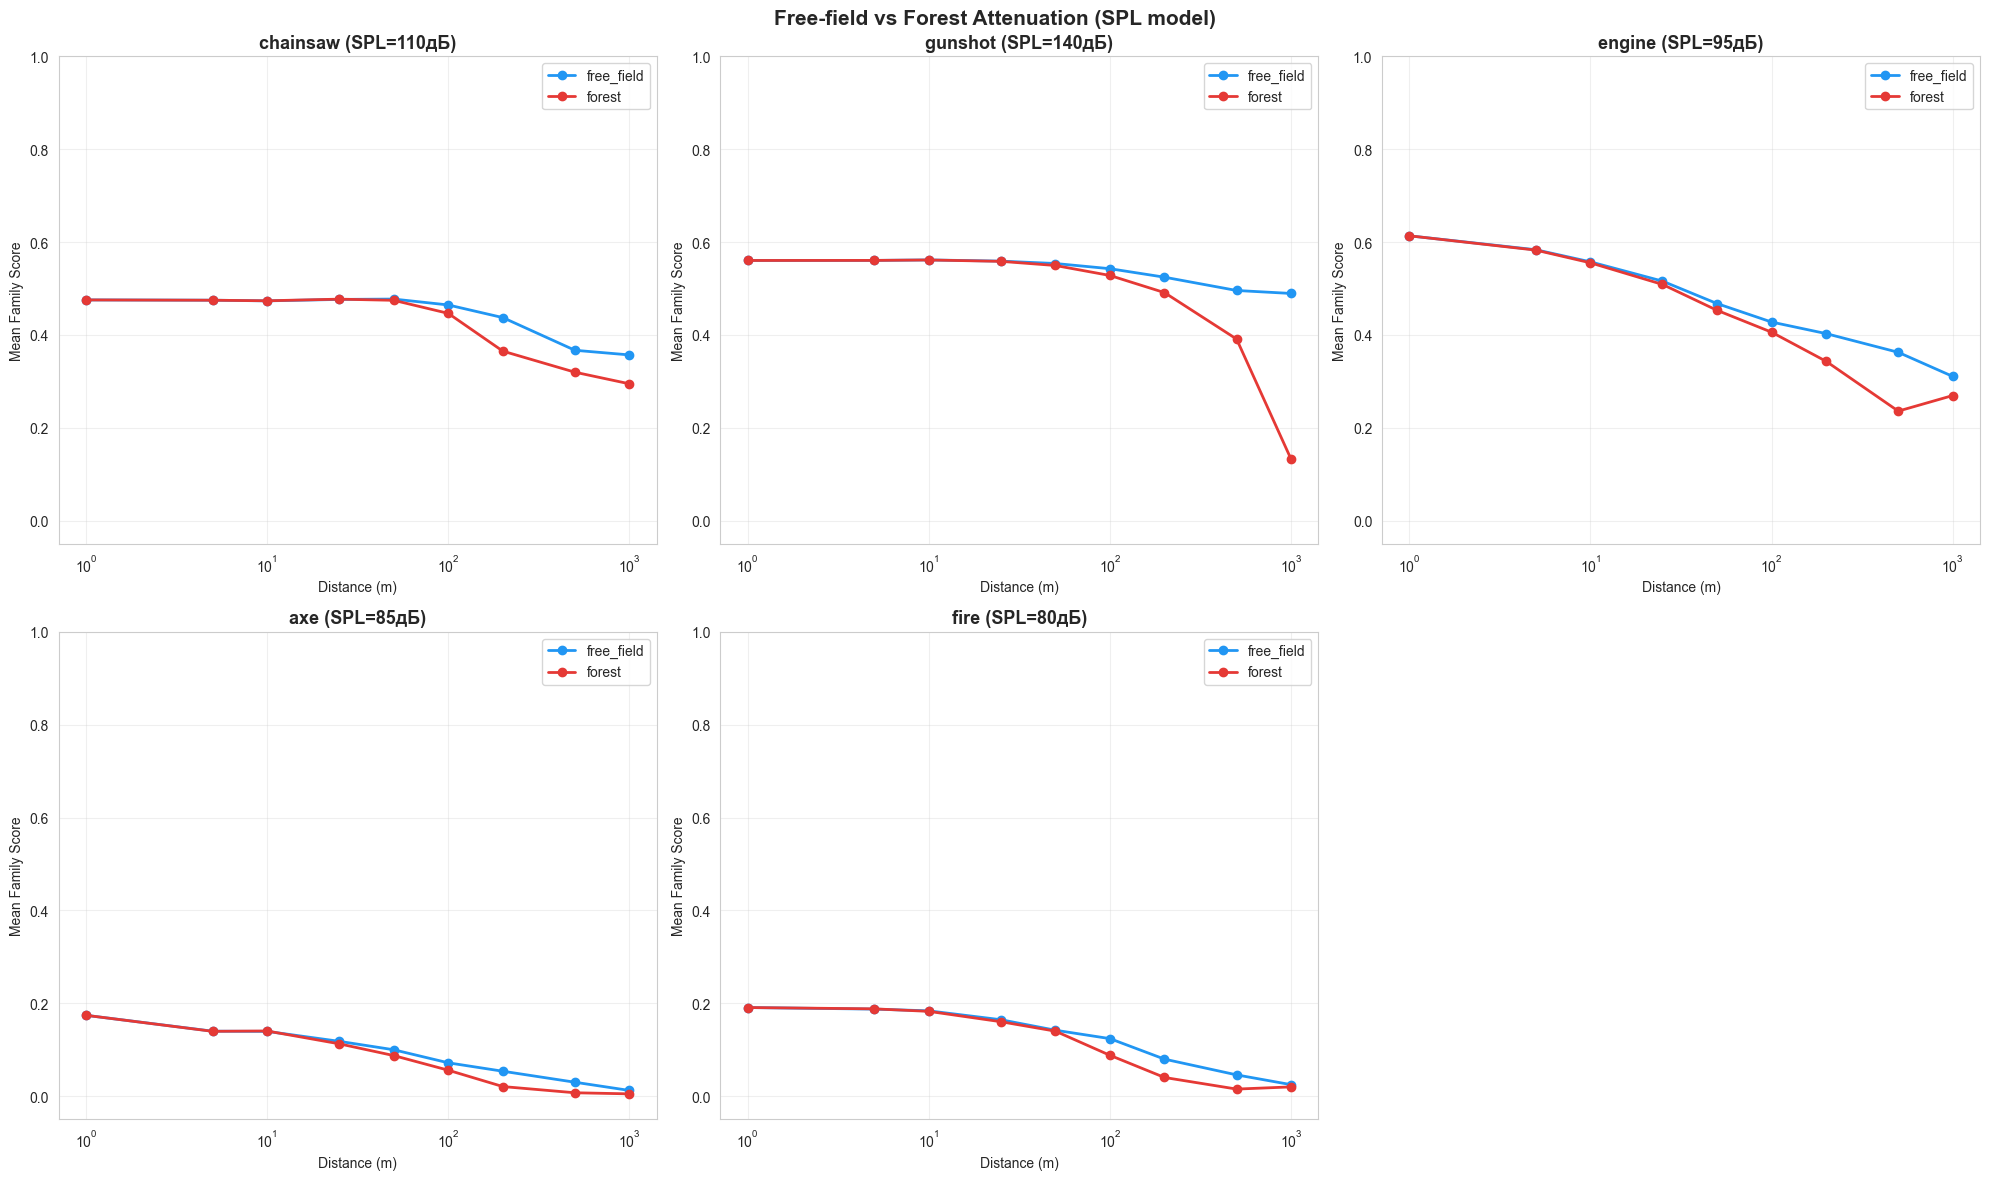

In [7]:
# Distance vs Score (free-field vs forest)
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
colors = {'free_field': '#2196F3', 'forest': '#E53935'}

for ax, target in zip(axes.flat, ALL_TARGETS):
    for atten, color in colors.items():
        sub = dist_df[(dist_df['target_class'] == target) & (dist_df['atten_model'] == atten)]
        mean = sub.groupby('distance_m')['target_score_family'].mean()
        ax.plot(mean.index, mean.values, marker='o', color=color, linewidth=2, label=atten)
    ax.set_xscale('log')
    ax.set_title(f'{target} (SPL={SOURCE_SPL[target]}дБ)', fontsize=13, fontweight='bold')
    ax.set_xlabel('Distance (m)')
    ax.set_ylabel('Mean Family Score')
    ax.set_ylim(-0.05, 1.0)
    ax.legend()
    ax.grid(True, alpha=0.3)

axes.flat[-1].set_visible(False)
plt.suptitle('Free-field vs Forest Attenuation (SPL model)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'distance_free_vs_forest.png', dpi=150, bbox_inches='tight')
plt.show()

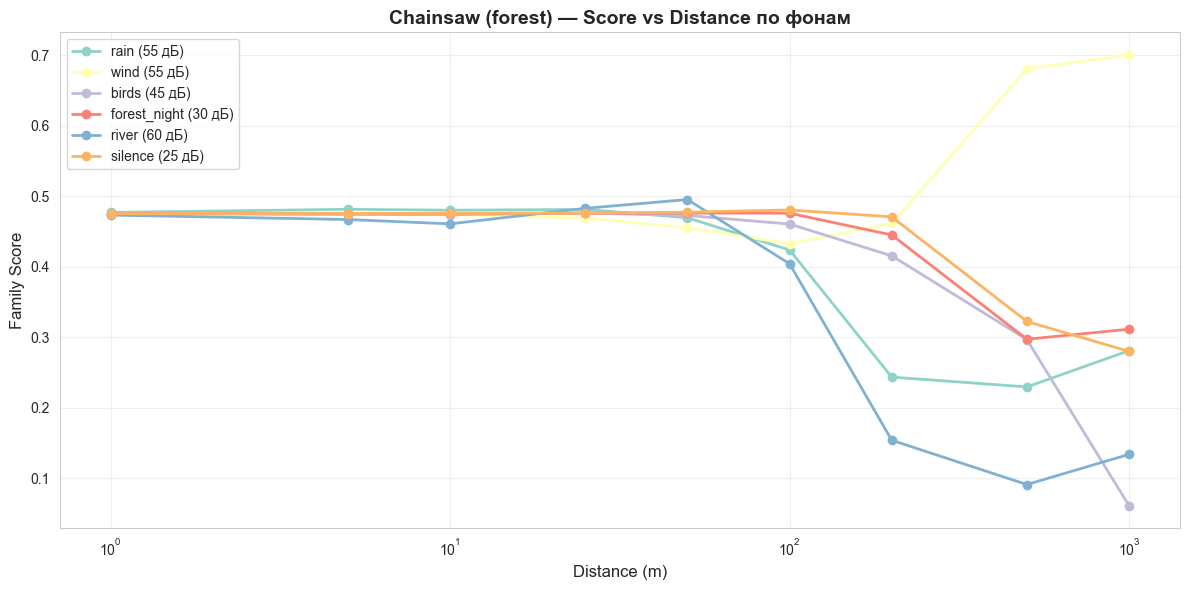

In [8]:
# Confidence vs distance by background (chainsaw, forest)
fig, ax = plt.subplots(figsize=(12, 6))
sub = dist_df[(dist_df['target_class'] == 'chainsaw') & (dist_df['atten_model'] == 'forest')]

for bg in bg_audio.keys():
    bg_sub = sub[sub['background'] == bg]
    mean = bg_sub.groupby('distance_m')['target_score_family'].mean()
    ax.plot(mean.index, mean.values, marker='o', linewidth=2, label=f'{bg} ({NOISE_SPL_MAP.get(bg, "?")} дБ)')

ax.set_xscale('log')
ax.set_xlabel('Distance (m)', fontsize=12)
ax.set_ylabel('Family Score', fontsize=12)
ax.set_title('Chainsaw (forest) — Score vs Distance по фонам', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'distance_by_background.png', dpi=150, bbox_inches='tight')
plt.show()

## Секция 5 — TDOA-триангуляция с реалистичными помехами (v5)

**v4 -> v5 изменения:**

1. **Fix 0.1:** GCC-PHAT — убран `abs()` в `np.argmax` (выбирал anti-correlation пики)
2. **Fix 0.2:** Bandpass regression fix — adaptive bandpass 1000-3000 Hz вместо 500-4000 Hz
3. **Fix 0.3:** `amplitude_localize()` — использует реальный RMS для оценки дистанции
4. **3.1:** Subpixel interpolation (квадратичная) — убирает квантизацию ±0.5 сэмпла
5. **3.2:** PHAT-beta (beta=0.75) — мягкое отбеливание для лесной реверберации
6. **3.3:** Median GCC accumulation (30 фреймов) — для непрерывных звуков
7. **3.4:** MAD outlier rejection — подавление выбросов от multipath
8. **3.5:** Early-peak selection — выбор прямого пути вместо максимума
9. **3.6:** DEMON для engine — демодуляция узкополосного сигнала
10. **3.7:** Spectral subtraction — подавление стационарного шума перед GCC

In [9]:
def create_triangle_array(center, spacing):
    """Равносторонний треугольник микрофонов."""
    cx, cy = center
    h = spacing * np.sqrt(3) / 2
    return np.array([
        [cx - spacing/2, cy - h/3],
        [cx + spacing/2, cy - h/3],
        [cx, cy + 2*h/3],
    ])


# === v5 3.1: Subpixel interpolation ===
def subpixel_peak(cc, peak_idx):
    """Квадратичная интерполяция для субсэмпловой точности TDOA.
    Убирает квантизационную ошибку ±0.5 сэмпла (при 16 kHz = ±21 мм на паре).
    """
    if peak_idx <= 0 or peak_idx >= len(cc) - 1:
        return float(peak_idx)
    y_m, y_0, y_p = cc[peak_idx - 1], cc[peak_idx], cc[peak_idx + 1]
    denom = y_m - 2 * y_0 + y_p
    if abs(denom) < 1e-10:
        return float(peak_idx)
    return peak_idx + 0.5 * (y_m - y_p) / denom


# === v5 3.5: Early-peak selection ===
def early_peak_selection(cc, center, max_delay_samples, prominence_ratio=0.3):
    """Выбирает ранний значимый пик GCC (прямой путь), а не просто argmax.
    Подавляет multipath (отражения от деревьев приходят позже прямого пути).
    """
    from scipy.signal import find_peaks
    start = max(0, center - max_delay_samples)
    end = min(len(cc), center + max_delay_samples + 1)
    search_region = cc[start:end]

    if len(search_region) == 0:
        return center

    max_val = np.max(search_region)
    if max_val <= 0:
        return center

    peaks, properties = find_peaks(search_region, prominence=prominence_ratio * max_val)
    if len(peaks) == 0:
        return start + np.argmax(search_region)

    # Выбираем ближайший к центру значимый пик (прямой путь)
    local_center = center - start
    closest_idx = np.argmin(np.abs(peaks - local_center))
    return start + peaks[closest_idx]


# === v5 3.7: Spectral subtraction ===
def spectral_subtract(signal, noise_estimate, alpha=2.0, beta=0.05):
    """Подавление стационарного шума (дождь) перед GCC.
    S_clean = max(|S| - alpha*|N|, beta*|S|) * exp(j*angle(S))
    """
    n_fft = 2 ** int(np.ceil(np.log2(len(signal))))
    S = np.fft.rfft(signal, n=n_fft)
    N = np.fft.rfft(noise_estimate, n=n_fft)

    mag_S = np.abs(S)
    mag_N = np.abs(N)
    phase_S = np.angle(S)

    mag_clean = np.maximum(mag_S - alpha * mag_N, beta * mag_S)
    S_clean = mag_clean * np.exp(1j * phase_S)

    return np.fft.irfft(S_clean, n=n_fft)[:len(signal)].astype(np.float32)


def gcc_phat(sig1, sig2, sr, max_delay_sec=None, beta=1.0,
             use_early_peak=False, use_subpixel=True):
    """GCC-PHAT кросс-корреляция для оценки TDOA.

    v5 изменения:
    - Fix 0.1: убран abs() в argmax — выбирал anti-correlation пики
    - 3.1: subpixel interpolation для субсэмпловой точности
    - 3.2: PHAT-beta (beta<1.0) для мягкого отбеливания
    - 3.5: early-peak selection для подавления multipath
    """
    n = len(sig1) + len(sig2) - 1
    n_fft = 2 ** int(np.ceil(np.log2(n)))

    S1 = np.fft.rfft(sig1, n=n_fft)
    S2 = np.fft.rfft(sig2, n=n_fft)

    R = S1 * np.conj(S2)
    denom = np.abs(R)
    denom[denom < 1e-10] = 1e-10
    # v5 3.2: PHAT-beta — beta=0.75 оптимален для лесной реверберации
    R_phat = R / (denom ** beta + 1e-10)

    cc = np.fft.irfft(R_phat, n=n_fft)
    cc = np.concatenate([cc[-(n_fft // 2):], cc[:n_fft // 2 + 1]])

    center = n_fft // 2

    if max_delay_sec is not None:
        max_samples = int(max_delay_sec * sr)
    else:
        max_samples = n_fft // 2

    if use_early_peak:
        # v5 3.5: early-peak selection — прямой путь вместо argmax
        peak_idx = early_peak_selection(cc, center, max_samples)
    else:
        start = max(0, center - max_samples)
        end = min(len(cc), center + max_samples + 1)
        search_cc = cc[start:end]
        # v5 Fix 0.1: убран abs() — anti-correlation пики не должны выбираться
        peak_idx = start + np.argmax(search_cc)

    if use_subpixel:
        # v5 3.1: subpixel interpolation
        refined_peak = subpixel_peak(cc, peak_idx)
        delay_sec = (refined_peak - center) / sr
    else:
        delay_sec = (peak_idx - center) / sr

    return delay_sec, cc


def gcc_phat_filtered(sig1, sig2, sr, max_delay_sec=None,
                      bandpass=None, filter_order=6,
                      beta=1.0, use_early_peak=False, use_subpixel=True,
                      noise_estimate=None):
    """v5: GCC-PHAT с опциональным bandpass, spectral subtraction, PHAT-beta.

    v4 -> v5:
    - Fix 0.2: adaptive bandpass 1000-3000 Hz (было 500-4000 Hz)
    - 3.2: beta parameter для PHAT-beta
    - 3.5: early-peak selection
    - 3.7: spectral subtraction перед GCC
    """
    s1 = sig1.copy()
    s2 = sig2.copy()

    # v5 3.7: Spectral subtraction (подавление дождя/ветра перед GCC)
    if noise_estimate is not None:
        s1 = spectral_subtract(s1, noise_estimate)
        s2 = spectral_subtract(s2, noise_estimate)

    if bandpass is not None:
        low, high = bandpass
        nyq = sr / 2
        sos = scipy_signal.butter(filter_order,
                                  [low / nyq, high / nyq],
                                  btype='bandpass', output='sos')
        s1 = scipy_signal.sosfiltfilt(sos, s1).astype(np.float32)
        s2 = scipy_signal.sosfiltfilt(sos, s2).astype(np.float32)

    return gcc_phat(s1, s2, sr, max_delay_sec, beta=beta,
                    use_early_peak=use_early_peak, use_subpixel=use_subpixel)


# === v5 3.6: DEMON для engine ===
def demon_gcc(sig1, sig2, sr, max_delay_sec=None, mod_cutoff=80):
    """DEMON (Detection of Envelope Modulation On Noise) для узкополосных сигналов.

    Для engine (50-200 Hz): broadband -> Hilbert envelope -> lowpass -> GCC-PHAT.
    Преобразует узкополосный сигнал в широкополосную огибающую.
    """
    from scipy.signal import hilbert

    # Bandpass 100-4000 Hz для broadband
    nyq = sr / 2
    sos_bp = scipy_signal.butter(4, [100 / nyq, 4000 / nyq], btype='bandpass', output='sos')
    s1_bp = scipy_signal.sosfiltfilt(sos_bp, sig1).astype(np.float32)
    s2_bp = scipy_signal.sosfiltfilt(sos_bp, sig2).astype(np.float32)

    # Hilbert envelope
    env1 = np.abs(hilbert(s1_bp)).astype(np.float32)
    env2 = np.abs(hilbert(s2_bp)).astype(np.float32)

    # Lowpass на модуляционную частоту двигателя (33-100 Hz)
    sos_lp = scipy_signal.butter(4, mod_cutoff / nyq, btype='lowpass', output='sos')
    env1_filt = scipy_signal.sosfiltfilt(sos_lp, env1).astype(np.float32)
    env2_filt = scipy_signal.sosfiltfilt(sos_lp, env2).astype(np.float32)

    return gcc_phat(env1_filt, env2_filt, sr, max_delay_sec,
                    beta=0.75, use_subpixel=True)


# === v5 3.3: Median GCC accumulation ===
def median_gcc_tdoa(sig1, sig2, sr, max_delay_sec=None,
                    frame_len_sec=1.0, n_frames=30,
                    bandpass=None, beta=0.75, noise_estimate=None):
    """Median GCC accumulation для непрерывных звуков (chainsaw, engine).

    Разбивает сигнал на фреймы, вычисляет GCC для каждого,
    берёт медиану по фреймам — подавляет случайные multipath.
    """
    frame_len = int(frame_len_sec * sr)
    total_len = min(len(sig1), len(sig2))
    actual_frames = min(n_frames, total_len // frame_len)

    if actual_frames < 3:
        # Недостаточно данных, используем обычный GCC
        return gcc_phat_filtered(sig1, sig2, sr, max_delay_sec,
                                 bandpass=bandpass, beta=beta,
                                 noise_estimate=noise_estimate)

    delays = []
    for f in range(actual_frames):
        start = f * frame_len
        end = start + frame_len
        frame1 = sig1[start:end]
        frame2 = sig2[start:end]

        delay, _ = gcc_phat_filtered(frame1, frame2, sr, max_delay_sec,
                                     bandpass=bandpass, beta=beta,
                                     use_subpixel=True,
                                     noise_estimate=noise_estimate)
        delays.append(delay)

    delays = np.array(delays)
    # v5 3.4: MAD outlier rejection
    robust_delay = mad_robust_estimate(delays)
    cc_dummy = np.zeros(1)
    return robust_delay, cc_dummy


# === v5 3.4: MAD outlier rejection ===
def mad_robust_estimate(estimates, threshold=2.5):
    """MAD (Median Absolute Deviation) для робастной оценки TDOA.
    Подавляет выбросы от multipath.
    """
    estimates = np.asarray(estimates)
    if len(estimates) < 3:
        return np.median(estimates)
    med = np.median(estimates)
    mad = np.median(np.abs(estimates - med)) * 1.4826  # scale to sigma
    if mad < 1e-10:
        return med
    mask = np.abs(estimates - med) < threshold * mad
    if mask.any():
        return np.mean(estimates[mask])
    return med


# v5 Fix 0.2: Обновлённая конфигурация bandpass по типу сигнала
SIGNAL_BANDPASS = {
    'gunshot':  None,             # wideband импульсный — полный спектр ОК
    'chainsaw': (1000, 3000),     # v5: narrower band (v4 было 500-4000 — регрессия!)
    'engine':   None,             # используем DEMON (v5 3.6) вместо bandpass
}

# v5: Конфигурация PHAT-beta по типу сигнала
SIGNAL_BETA = {
    'gunshot':  1.0,    # полное отбеливание — импульсный сигнал не нуждается в смягчении
    'chainsaw': 0.75,   # v5 3.2: мягкое отбеливание для лесной реверберации
    'engine':   0.75,   # используется внутри DEMON
}

# v5: Метод TDOA по типу сигнала
SIGNAL_TDOA_METHOD = {
    'gunshot':  'gcc_phat',       # одиночный импульс — стандартный GCC
    'chainsaw': 'median_gcc',     # непрерывный — median accumulation
    'engine':   'demon',          # узкополосный — DEMON + GCC
}

# v4 Fix 8: Режимы синхронизации часов
JITTER_MODES = {
    'no_gps': 1.0,    # sigma=1 sample (62.5us), worst-case (NTP over LoRa)
    'gps_pps': 0.1,   # sigma=0.1 sample (6.25us), GPS PPS sync
}


def tdoa_localize_2d(mic_positions, tdoa_pairs):
    """Гиперболическая локализация через нелинейный least-squares."""
    def residuals(pos):
        x, y = pos
        res = []
        for i, j, tdoa in tdoa_pairs:
            di = np.sqrt((x - mic_positions[i, 0])**2 + (y - mic_positions[i, 1])**2)
            dj = np.sqrt((x - mic_positions[j, 0])**2 + (y - mic_positions[j, 1])**2)
            predicted_tdoa = (di - dj) / SPEED_OF_SOUND
            res.append(predicted_tdoa - tdoa)
        return res

    x0 = mic_positions.mean(axis=0)
    result = least_squares(residuals, x0, method='lm')
    return result.x


# === Impairment functions (unchanged from v3) ===

def fractional_delay(signal, delay_samples_float, sr):
    """Apply fractional delay using windowed sinc interpolation (FIR, length 21)."""
    int_delay = int(np.floor(delay_samples_float))
    frac_delay = delay_samples_float - int_delay

    if abs(frac_delay) < 1e-9:
        return int_delay, signal

    N = 21
    half = N // 2
    n = np.arange(N) - half
    h = np.sinc(n - frac_delay)
    h *= np.hanning(N)
    h /= np.sum(h)

    delayed_signal = np.convolve(signal, h, mode='full')
    delayed_signal = delayed_signal[half:half + len(signal)]

    return int_delay, delayed_signal.astype(np.float32)


def add_multipath(signal, sr, n_reflections=None, rng=None):
    """Add forest multipath reflections (2-5 reflections, 5-50ms delay, 0.2-0.6 amplitude)."""
    if rng is None:
        rng = np.random.RandomState()
    if n_reflections is None:
        n_reflections = rng.randint(2, 6)

    result = signal.copy()
    for _ in range(n_reflections):
        delay_ms = rng.uniform(5.0, 50.0)
        delay_samples = int(delay_ms * sr / 1000.0)
        amplitude = rng.uniform(0.2, 0.6)
        phase = rng.choice([-1, 1])

        if delay_samples < len(signal):
            reflected = np.zeros_like(signal)
            reflected[delay_samples:] = signal[:-delay_samples] * amplitude * phase
            result += reflected

    return result


def apply_clock_jitter(delay_samples_float, jitter_sigma_samples=1.0, rng=None):
    """Add Gaussian clock jitter."""
    if rng is None:
        rng = np.random.RandomState()
    jitter = rng.normal(0, jitter_sigma_samples)
    return delay_samples_float + jitter


def get_wind_speed_of_sound(base_c=343.0, wind_sigma=0.02, rng=None):
    """Speed of sound with wind variation."""
    if rng is None:
        rng = np.random.RandomState()
    delta = rng.normal(0, wind_sigma)
    return base_c * (1 + delta)


def simulate_tdoa_event_v3(source_pos, mic_positions, signal, bg_audio_clip,
                           source_spl, noise_spl, sr=TARGET_SR,
                           excess_atten=DEFAULT_EXCESS_ATTEN,
                           enable_multipath=True,
                           enable_jitter=True, jitter_sigma=1.0,
                           enable_fractional=True,
                           enable_wind=True, wind_sigma=0.02,
                           rng=None):
    """Simulate signal reception on mic array with realistic impairments."""
    if rng is None:
        rng = np.random.RandomState()

    n_mics = len(mic_positions)
    distances = np.array([np.linalg.norm(source_pos - m) for m in mic_positions])

    if enable_wind:
        effective_c = get_wind_speed_of_sound(SPEED_OF_SOUND, wind_sigma, rng)
    else:
        effective_c = SPEED_OF_SOUND

    true_delays = distances / SPEED_OF_SOUND
    sim_delays = distances / effective_c

    max_delay_samples = int(np.max(sim_delays) * sr) + 100
    sig_len = len(signal) + max_delay_samples + sr

    mic_signals = []
    for i in range(n_mics):
        snr_at_mic = compute_realistic_snr(source_spl, noise_spl,
                                            max(distances[i], 1.0), excess_atten)

        delay_samples_float = sim_delays[i] * sr

        if enable_jitter:
            delay_samples_float = apply_clock_jitter(delay_samples_float, jitter_sigma, rng)

        if enable_fractional:
            int_delay, delayed_signal = fractional_delay(signal, delay_samples_float, sr)
        else:
            int_delay = int(delay_samples_float)
            delayed_signal = signal

        padded = np.zeros(sig_len, dtype=np.float32)
        start = max(int_delay, 0)
        sig_start = max(0, -int_delay)
        end = min(start + len(delayed_signal) - sig_start, sig_len)
        padded[start:end] = delayed_signal[sig_start:sig_start + (end - start)]

        if enable_multipath:
            padded = add_multipath(padded, sr, rng=rng)

        noise = bg_audio_clip.copy()
        if len(noise) < sig_len:
            noise = np.tile(noise, int(np.ceil(sig_len / len(noise))))[:sig_len]
        else:
            noise = noise[:sig_len]

        mic_sig = mix_with_snr(padded, noise, snr_at_mic)
        mic_signals.append(mic_sig)

    return mic_signals, distances, true_delays, effective_c


# Массив микрофонов
MIC_SPACING = 200  # м
mic_positions = create_triangle_array(center=(0, 0), spacing=MIC_SPACING)
print(f'Микрофоны (треугольник {MIC_SPACING}м):')
for i, pos in enumerate(mic_positions):
    print(f'  M{i}: ({pos[0]:.0f}, {pos[1]:.0f}) м')

print(f'\nv5 Signal config:')
print(f'  Bandpass: {SIGNAL_BANDPASS}')
print(f'  PHAT-beta: {SIGNAL_BETA}')
print(f'  TDOA method: {SIGNAL_TDOA_METHOD}')
print(f'  Jitter modes: {JITTER_MODES}')

Микрофоны (треугольник 200м):
  M0: (-100, -58) м
  M1: (100, -58) м
  M2: (0, 115) м

v5 Signal config:
  Bandpass: {'gunshot': None, 'chainsaw': (1000, 3000), 'engine': None}
  PHAT-beta: {'gunshot': 1.0, 'chainsaw': 0.75, 'engine': 0.75}
  TDOA method: {'gunshot': 'gcc_phat', 'chainsaw': 'median_gcc', 'engine': 'demon'}
  Jitter modes: {'no_gps': 1.0, 'gps_pps': 0.1}


In [10]:
rng = np.random.RandomState(42)
N_EVENTS = 50
max_delay = MIC_SPACING / SPEED_OF_SOUND * 1.5

# Test signal types
TDOA_SIGNALS = {
    'gunshot': {'samples': target_samples['gunshot'][0], 'spl': SOURCE_SPL['gunshot'],
                'type': 'impulsive'},
    'chainsaw': {'samples': target_samples['chainsaw'][0], 'spl': SOURCE_SPL['chainsaw'],
                 'type': 'stationary'},
    'engine': {'samples': target_samples['engine'][0], 'spl': SOURCE_SPL['engine'],
               'type': 'stationary'},
}

# Test zones
TDOA_ZONES = {
    'inside': {'range': (-50, 50), 'description': 'Inside array (50m)'},
    'edge':   {'range': (-150, 150), 'description': 'Array edge (150m)'},
    'outside': {'range': (-300, 300), 'description': 'Outside array (300m)'},
}

# Background conditions
TDOA_BACKGROUNDS = {
    'quiet': {'audio': bg_audio.get('birds', list(bg_audio.values())[0]),
              'spl': NOISE_SPL_MAP.get('birds', 45), 'name': 'birds (45dB)'},
    'noisy': {'audio': bg_audio.get('rain', list(bg_audio.values())[0]),
              'spl': NOISE_SPL_MAP.get('rain', 55), 'name': 'rain (55dB)'},
}

all_tdoa_results = []

for sig_name, sig_info in TDOA_SIGNALS.items():
    # v5: выбираем метод и параметры по типу сигнала
    bandpass = SIGNAL_BANDPASS.get(sig_name, None)
    beta = SIGNAL_BETA.get(sig_name, 1.0)
    method = SIGNAL_TDOA_METHOD.get(sig_name, 'gcc_phat')

    for zone_name, zone_info in TDOA_ZONES.items():
        for bg_label, bg_info in TDOA_BACKGROUNDS.items():
            lo, hi = zone_info['range']
            source_positions = rng.uniform(lo, hi, size=(N_EVENTS, 2))

            # v5 3.7: оценка шума для spectral subtraction (первые 0.5 сек фона)
            noise_est = bg_info['audio'][:int(0.5 * TARGET_SR)] if bg_label == 'noisy' else None

            for ev_idx in range(N_EVENTS):
                src = source_positions[ev_idx]

                mic_sigs, true_dists, true_delays, eff_c = simulate_tdoa_event_v3(
                    src, mic_positions,
                    sig_info['samples'], bg_info['audio'],
                    sig_info['spl'], bg_info['spl'],
                    rng=rng,
                )

                pairs = [(0, 1), (0, 2), (1, 2)]
                tdoa_pairs = []
                for i, j in pairs:
                    # v5: выбираем метод TDOA по типу сигнала
                    if method == 'median_gcc':
                        delay, _ = median_gcc_tdoa(
                            mic_sigs[i], mic_sigs[j], TARGET_SR,
                            max_delay_sec=max_delay,
                            bandpass=bandpass, beta=beta,
                            noise_estimate=noise_est,
                        )
                    elif method == 'demon':
                        delay, _ = demon_gcc(
                            mic_sigs[i], mic_sigs[j], TARGET_SR,
                            max_delay_sec=max_delay,
                        )
                    else:  # gcc_phat (gunshot)
                        delay, _ = gcc_phat_filtered(
                            mic_sigs[i], mic_sigs[j], TARGET_SR,
                            max_delay_sec=max_delay,
                            bandpass=bandpass, beta=beta,
                            use_early_peak=(sig_name != 'gunshot'),
                            use_subpixel=True,
                            noise_estimate=noise_est,
                        )
                    tdoa_pairs.append((i, j, delay))

                estimated = tdoa_localize_2d(mic_positions, tdoa_pairs)
                error = np.linalg.norm(estimated - src)

                nearest_dist = np.min(true_dists)
                snr_nearest = compute_realistic_snr(sig_info['spl'], bg_info['spl'],
                                                     max(nearest_dist, 1.0))

                all_tdoa_results.append({
                    'signal': sig_name,
                    'zone': zone_name,
                    'background': bg_label,
                    'event': ev_idx,
                    'true_x': src[0], 'true_y': src[1],
                    'est_x': estimated[0], 'est_y': estimated[1],
                    'error_m': error,
                    'nearest_dist': nearest_dist,
                    'snr_nearest': snr_nearest,
                    'method': method,
                })

    print(f'{sig_name} ({method}): done — {len(TDOA_ZONES) * len(TDOA_BACKGROUNDS) * N_EVENTS} events')

tdoa_df = pd.DataFrame(all_tdoa_results)
tdoa_df.to_csv(RESULTS_DIR / 'tdoa_results_v5.csv', index=False)

# Summary
print(f'\nTDOA v5 Summary:')
print(f'{"Signal":<12} {"Method":<12} {"Zone":<10} {"BG":<8} {"Median":<8} {"Mean":<8} {"P95":<8}')
print('-' * 66)
for sig_name in TDOA_SIGNALS:
    method = SIGNAL_TDOA_METHOD[sig_name]
    for zone_name in TDOA_ZONES:
        for bg_label in TDOA_BACKGROUNDS:
            sub = tdoa_df[(tdoa_df['signal'] == sig_name) &
                          (tdoa_df['zone'] == zone_name) &
                          (tdoa_df['background'] == bg_label)]
            if len(sub) == 0:
                continue
            print(f'{sig_name:<12} {method:<12} {zone_name:<10} {bg_label:<8} '
                  f'{sub["error_m"].median():<8.1f} '
                  f'{sub["error_m"].mean():<8.1f} '
                  f'{sub["error_m"].quantile(0.95):<8.1f}')

gunshot (gcc_phat): done — 300 events
chainsaw (median_gcc): done — 300 events
engine (demon): done — 300 events

TDOA v5 Summary:
Signal       Method       Zone       BG       Median   Mean     P95     
------------------------------------------------------------------
gunshot      gcc_phat     inside     quiet    0.5      0.6      1.7     
gunshot      gcc_phat     inside     noisy    0.5      0.6      1.7     
gunshot      gcc_phat     edge       quiet    4.5      8.4      32.0    
gunshot      gcc_phat     edge       noisy    2.4      6.1      24.3    
gunshot      gcc_phat     outside    quiet    19.0     37.1     113.4   
gunshot      gcc_phat     outside    noisy    15.8     63.1     245.8   
chainsaw     median_gcc   inside     quiet    0.4      0.6      1.7     
chainsaw     median_gcc   inside     noisy    38.9     37.4     60.6    
chainsaw     median_gcc   edge       quiet    3.4      11.7     41.8    
chainsaw     median_gcc   edge       noisy    112.5    104.8    166.5   

## Секция 6 — TDOA графики (v5)

1. GCC-PHAT: gunshot vs chainsaw (показывает разницу multipath impact)
2. Localization map: 3 сигнала × inside zone

**v4 note:** Графики ниже показывают raw GCC-PHAT (без bandpass) для наглядности.
Bandpass filtering применяется в секции 5 (TDOA simulation) для chainsaw.

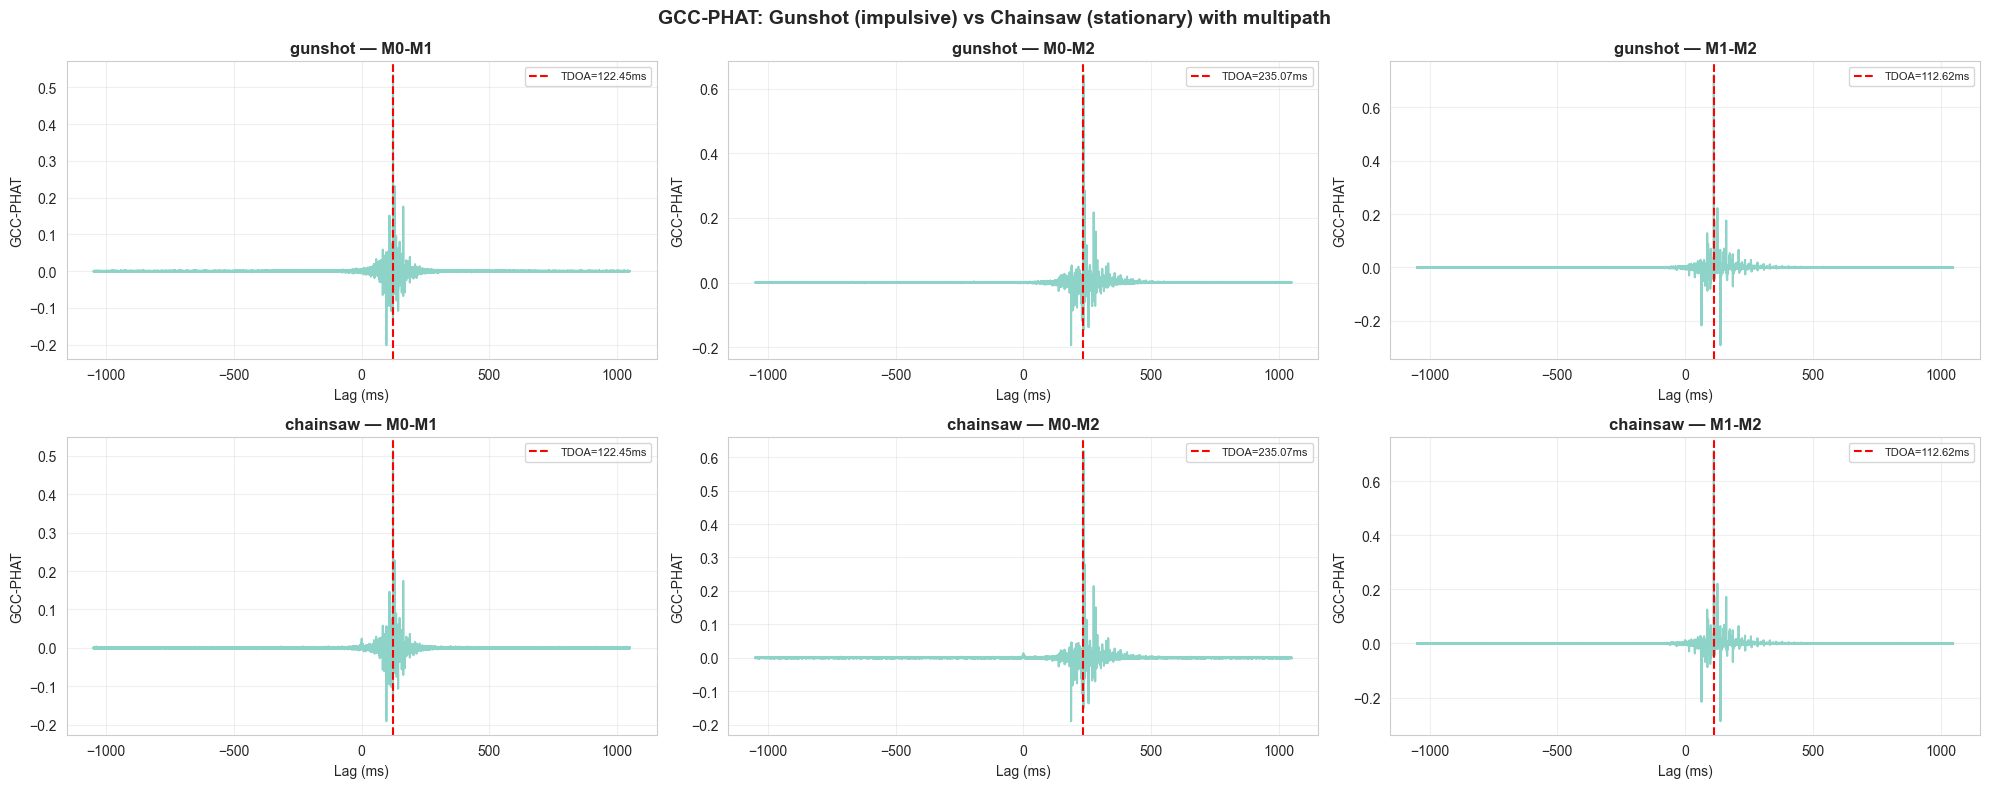

In [11]:
# GCC-PHAT comparison: gunshot (impulsive) vs chainsaw (stationary)
fig, axes = plt.subplots(2, 3, figsize=(20, 8))

for row, sig_name in enumerate(['gunshot', 'chainsaw']):
    sig_info = TDOA_SIGNALS[sig_name]
    src = np.array([30.0, 40.0])
    bg_info = TDOA_BACKGROUNDS['quiet']

    mic_sigs, _, _, _ = simulate_tdoa_event_v3(
        src, mic_positions, sig_info['samples'], bg_info['audio'],
        sig_info['spl'], bg_info['spl'],
        rng=np.random.RandomState(42),
    )

    pair_labels = ['M0-M1', 'M0-M2', 'M1-M2']
    pairs = [(0, 1), (0, 2), (1, 2)]

    for col, ((i, j), label) in enumerate(zip(pairs, pair_labels)):
        ax = axes[row, col]
        delay, cc = gcc_phat(mic_sigs[i], mic_sigs[j], TARGET_SR,
                              max_delay_sec=max_delay)
        n_fft = len(cc)
        lags = (np.arange(len(cc)) - n_fft // 2) / TARGET_SR * 1000
        center = n_fft // 2
        window = int(max_delay * TARGET_SR * 1.2)
        s, e = center - window, center + window
        ax.plot(lags[s:e], cc[s:e])
        ax.axvline(x=delay*1000, color='red', linestyle='--',
                    label=f'TDOA={delay*1000:.2f}ms')
        ax.set_title(f'{sig_name} — {label}', fontweight='bold')
        ax.set_xlabel('Lag (ms)')
        ax.set_ylabel('GCC-PHAT')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

plt.suptitle('GCC-PHAT: Gunshot (impulsive) vs Chainsaw (stationary) with multipath',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'gcc_phat_comparison_v5.png', dpi=150, bbox_inches='tight')
plt.show()

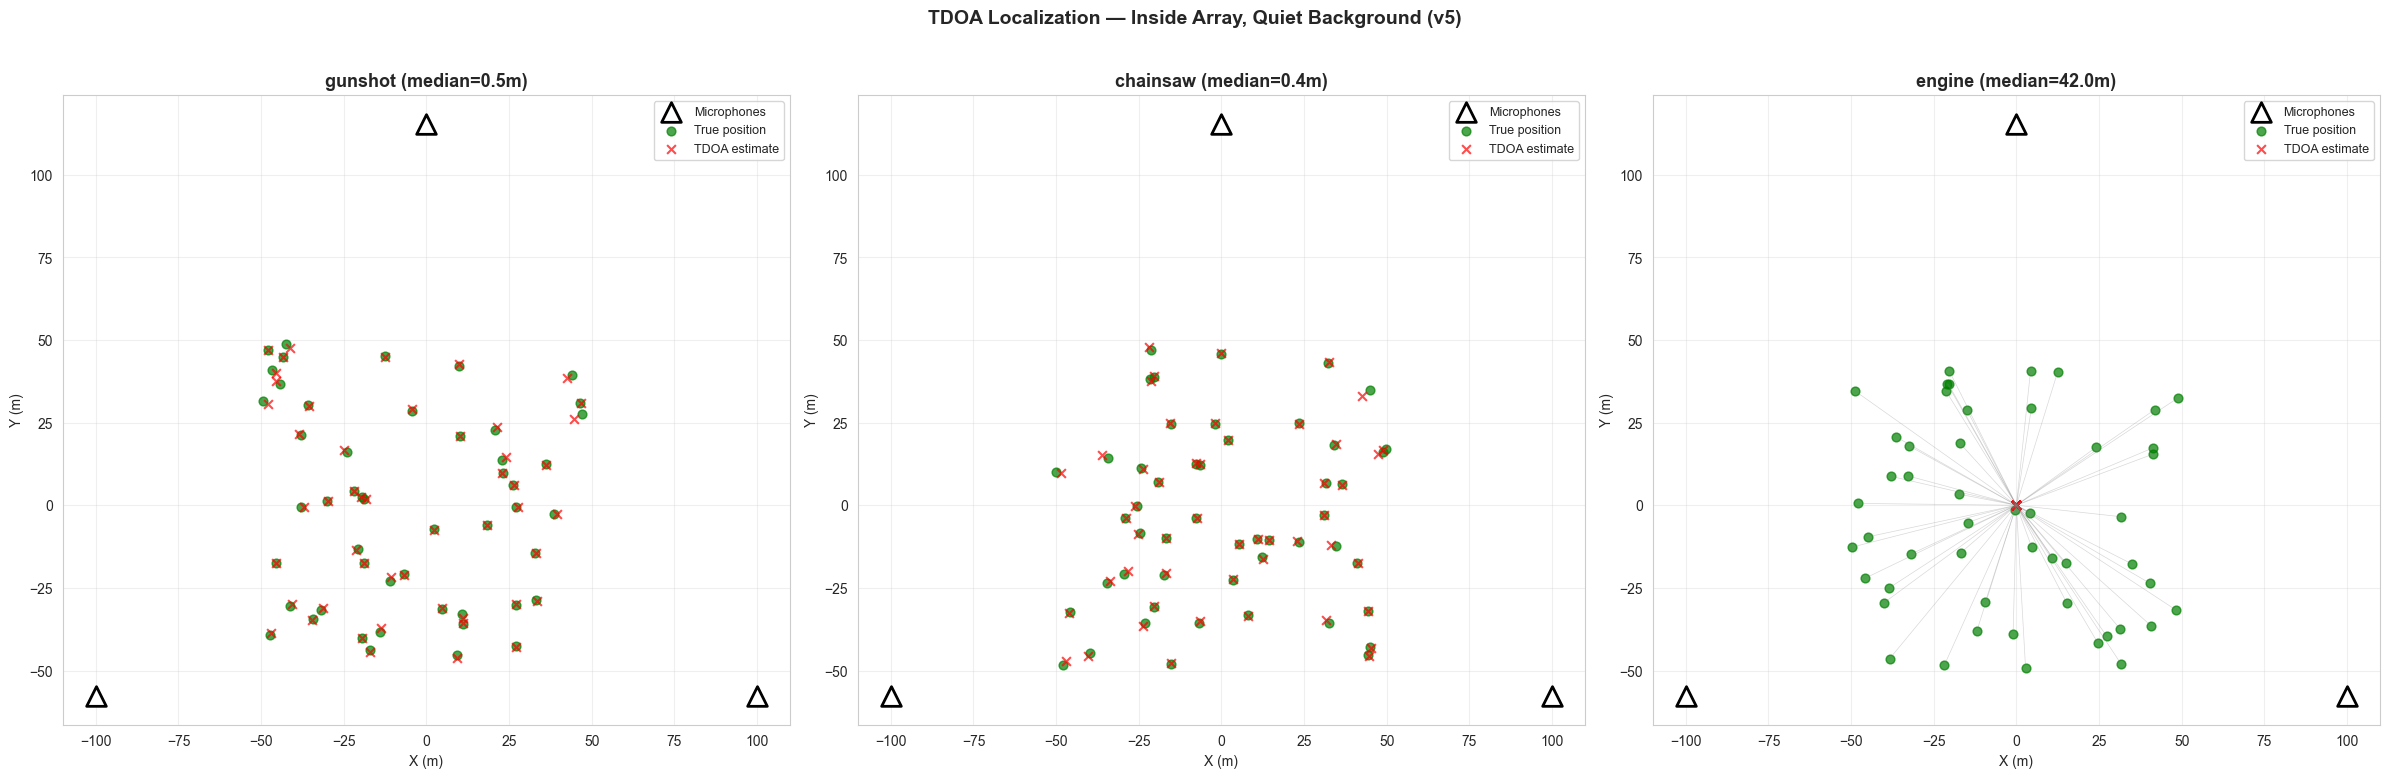

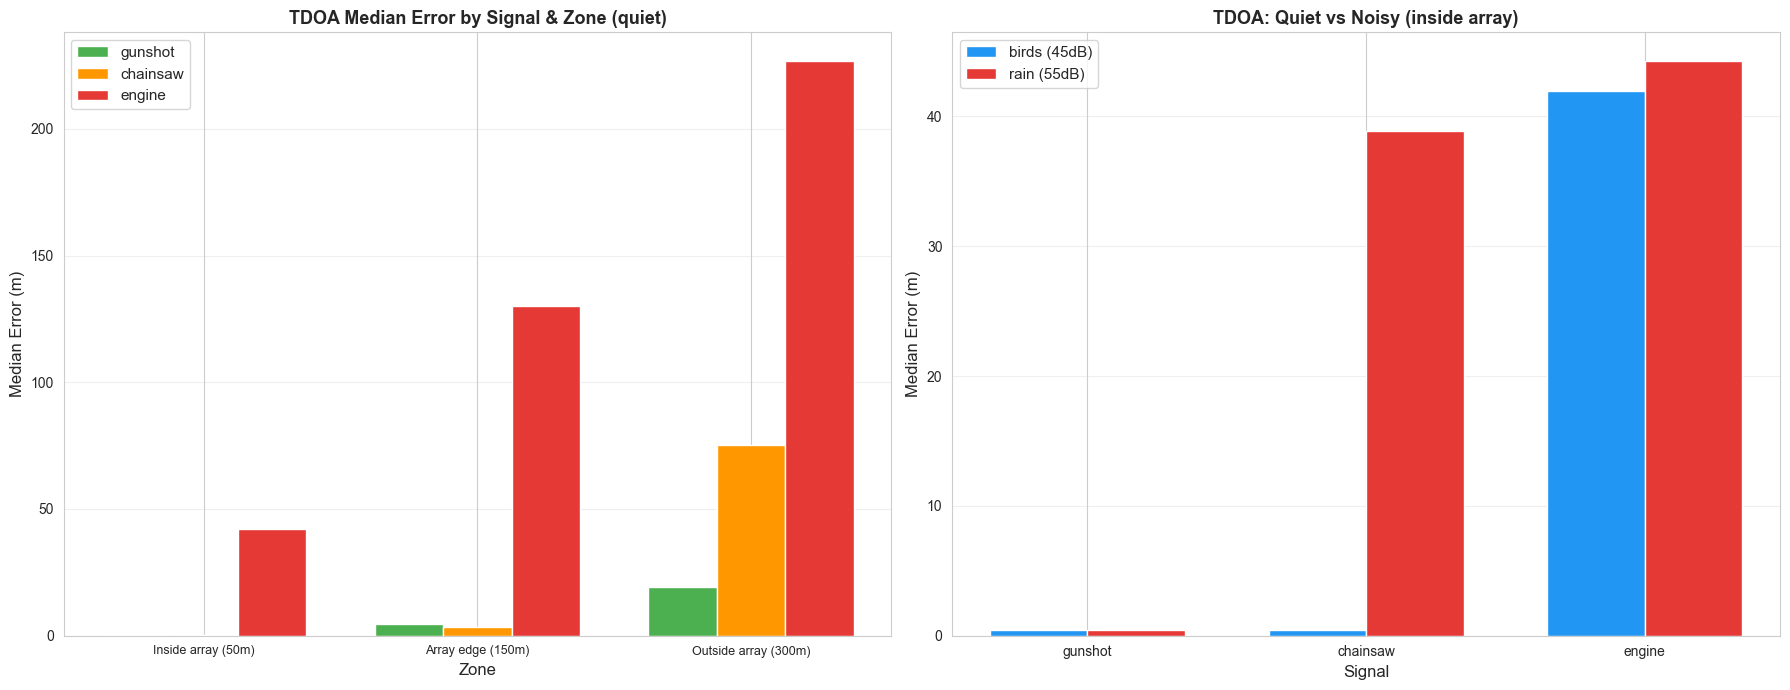

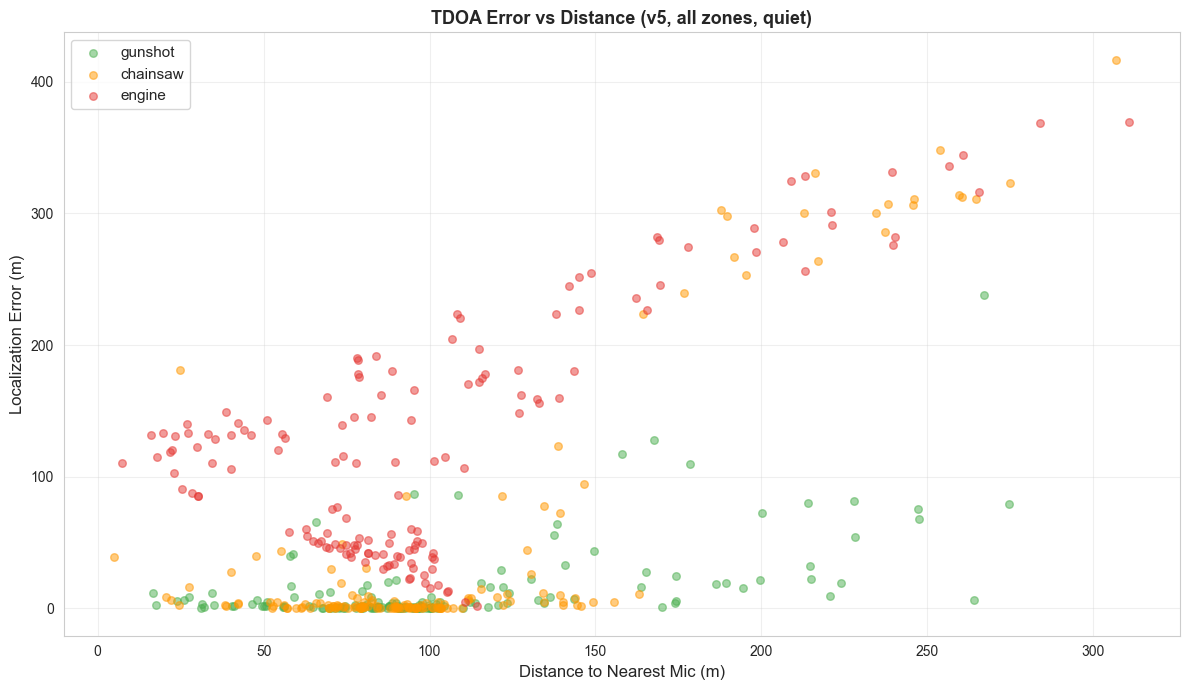

In [12]:
# Localization map: 3 signals x inside zone x quiet
fig, axes = plt.subplots(1, 3, figsize=(24, 8))
colors_sig = {'gunshot': '#4CAF50', 'chainsaw': '#FF9800', 'engine': '#E53935'}

for ax, sig_name in zip(axes, ['gunshot', 'chainsaw', 'engine']):
    sub = tdoa_df[(tdoa_df['signal'] == sig_name) &
                  (tdoa_df['zone'] == 'inside') &
                  (tdoa_df['background'] == 'quiet')]

    ax.scatter(mic_positions[:, 0], mic_positions[:, 1], marker='^', s=200,
               c='white', edgecolors='black', linewidth=2, zorder=5, label='Microphones')
    ax.scatter(sub['true_x'], sub['true_y'], c='green', s=40, alpha=0.7,
               label='True position')
    ax.scatter(sub['est_x'], sub['est_y'], c='red', s=40, marker='x',
               alpha=0.7, label='TDOA estimate')
    for _, row in sub.iterrows():
        ax.plot([row['true_x'], row['est_x']], [row['true_y'], row['est_y']],
                'gray', alpha=0.3, linewidth=0.5)

    median_err = sub['error_m'].median()
    ax.set_title(f'{sig_name} (median={median_err:.1f}m)', fontsize=13, fontweight='bold')
    ax.set_xlabel('X (m)')
    ax.set_ylabel('Y (m)')
    ax.legend(fontsize=9)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

plt.suptitle('TDOA Localization — Inside Array, Quiet Background (v5)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'tdoa_localization_v5.png', dpi=150, bbox_inches='tight')
plt.show()

# Error bar chart by signal/zone
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

ax = axes[0]
signals = list(TDOA_SIGNALS.keys())
zones = list(TDOA_ZONES.keys())
x = np.arange(len(zones))
width = 0.25

for i, sig in enumerate(signals):
    medians = []
    for zone in zones:
        sub = tdoa_df[(tdoa_df['signal'] == sig) &
                      (tdoa_df['zone'] == zone) &
                      (tdoa_df['background'] == 'quiet')]
        medians.append(sub['error_m'].median())
    ax.bar(x + i * width, medians, width, label=sig, color=list(colors_sig.values())[i])

ax.set_xlabel('Zone', fontsize=12)
ax.set_ylabel('Median Error (m)', fontsize=12)
ax.set_title('TDOA Median Error by Signal & Zone (quiet)', fontsize=13, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels([TDOA_ZONES[z]['description'] for z in zones], fontsize=9)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

ax = axes[1]
x2 = np.arange(len(signals))
for i, bg in enumerate(['quiet', 'noisy']):
    medians = []
    for sig in signals:
        sub = tdoa_df[(tdoa_df['signal'] == sig) &
                      (tdoa_df['zone'] == 'inside') &
                      (tdoa_df['background'] == bg)]
        medians.append(sub['error_m'].median())
    ax.bar(x2 + i * 0.35, medians, 0.35,
           label=TDOA_BACKGROUNDS[bg]['name'],
           color=['#2196F3', '#E53935'][i])

ax.set_xlabel('Signal', fontsize=12)
ax.set_ylabel('Median Error (m)', fontsize=12)
ax.set_title('TDOA: Quiet vs Noisy (inside array)', fontsize=13, fontweight='bold')
ax.set_xticks(x2 + 0.175)
ax.set_xticklabels(signals)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'tdoa_error_by_condition_v5.png', dpi=150, bbox_inches='tight')
plt.show()

# Error vs distance to nearest mic
fig, ax = plt.subplots(figsize=(12, 7))
for sig_name, color in colors_sig.items():
    sub = tdoa_df[(tdoa_df['signal'] == sig_name) & (tdoa_df['background'] == 'quiet')]
    ax.scatter(sub['nearest_dist'], sub['error_m'],
               c=color, s=30, alpha=0.5, label=sig_name)
ax.set_xlabel('Distance to Nearest Mic (m)', fontsize=12)
ax.set_ylabel('Localization Error (m)', fontsize=12)
ax.set_title('TDOA Error vs Distance (v5, all zones, quiet)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'tdoa_error_vs_distance_v5.png', dpi=150, bbox_inches='tight')
plt.show()

## Секция 6.5 — Amplitude-based localization для engine (v5 Fix 0.3)

### Исправление v4 -> v5

`estimate_ref_distance()` в v4 возвращала одно расстояние **независимо от реального сигнала** (бинарный поиск по фиксированному SNR=5).

**v5 fix:** используем реальный измеренный RMS для оценки SNR на reference mic, затем решаем уравнение распространения для distance.

In [13]:
def amplitude_localize(mic_positions, mic_signals, source_spl, noise_spl,
                       excess_atten=DEFAULT_EXCESS_ATTEN):
    """v5 Fix 0.3: Грубая локализация по амплитуде для narrowband сигналов (engine).

    v4 -> v5: estimate_ref_distance() теперь использует реальный измеренный SNR
    вместо фиксированного порога SNR=5.
    """
    rms_per_mic = np.array([np.sqrt(np.mean(s**2)) for s in mic_signals])

    # Ближайший микрофон как reference (максимальный RMS)
    ref_idx = np.argmax(rms_per_mic)
    rms_ref = rms_per_mic[ref_idx]

    # v5 Fix 0.3: оценка noise floor из самого тихого микрофона
    rms_min = np.min(rms_per_mic)

    # Оценка relative distances через RMS ratio + SPL модель
    est_distance_ratios = np.ones(len(mic_positions))
    for i in range(len(mic_positions)):
        if i == ref_idx:
            continue
        ratio = rms_per_mic[i] / (rms_ref + 1e-10)
        if ratio >= 1.0:
            est_distance_ratios[i] = 1.0
        else:
            est_distance_ratios[i] = 1.0 / max(ratio, 0.01)

    # v5 Fix 0.3: оценка d_ref через реальный measured SNR
    # SNR_measured ~= 20*log10(rms_ref / rms_min) (если rms_min ~ noise floor)
    # Затем: SNR_measured = source_spl - 20*log10(d_ref) - alpha*d_ref - noise_spl
    measured_snr = 20 * np.log10(rms_ref / (rms_min + 1e-10) + 1e-10)
    measured_snr = np.clip(measured_snr, 0, 60)

    def estimate_ref_distance_v5(measured_snr):
        """Бинарный поиск d_ref по реально измеренному SNR."""
        lo, hi = 1.0, 2000.0
        for _ in range(50):
            mid = (lo + hi) / 2
            expected_snr = compute_realistic_snr(source_spl, noise_spl, mid, excess_atten)
            if expected_snr > measured_snr:
                lo = mid
            else:
                hi = mid
        return max((lo + hi) / 2, 1.0)

    d_ref_est = estimate_ref_distance_v5(measured_snr)
    est_distances = est_distance_ratios * d_ref_est

    # Trilateration (least squares)
    def residuals(pos):
        return np.array([
            np.sqrt((pos[0] - mic_positions[i, 0])**2 +
                    (pos[1] - mic_positions[i, 1])**2) - est_distances[i]
            for i in range(len(mic_positions))
        ])

    result = least_squares(residuals, mic_positions[ref_idx], method='lm')
    return result.x, est_distances


# --- Тест amplitude localization для engine ---
print('Amplitude-based localization для engine (v5 Fix 0.3):')
print('=' * 70)

amp_results = []
rng_amp = np.random.RandomState(123)

for zone_name, zone_info in TDOA_ZONES.items():
    for bg_label, bg_info in TDOA_BACKGROUNDS.items():
        lo, hi = zone_info['range']
        source_positions = rng_amp.uniform(lo, hi, size=(N_EVENTS, 2))

        for ev_idx in range(N_EVENTS):
            src = source_positions[ev_idx]

            mic_sigs, true_dists, _, _ = simulate_tdoa_event_v3(
                src, mic_positions,
                target_samples['engine'][0], bg_info['audio'],
                SOURCE_SPL['engine'], bg_info['spl'],
                rng=rng_amp,
            )

            est_pos, est_dists = amplitude_localize(
                mic_positions, mic_sigs,
                SOURCE_SPL['engine'], bg_info['spl'],
            )
            error = np.linalg.norm(est_pos - src)

            amp_results.append({
                'zone': zone_name,
                'background': bg_label,
                'event': ev_idx,
                'true_x': src[0], 'true_y': src[1],
                'est_x': est_pos[0], 'est_y': est_pos[1],
                'error_m': error,
                'method': 'amplitude',
            })

amp_df = pd.DataFrame(amp_results)

print(f'\nEngine Amplitude Localization Summary (v5):')
print(f'{"Zone":<10} {"Background":<10} {"Median":<10} {"Mean":<10} {"P95":<10}')
print('-' * 50)
for zone_name in TDOA_ZONES:
    for bg_label in TDOA_BACKGROUNDS:
        sub = amp_df[(amp_df['zone'] == zone_name) & (amp_df['background'] == bg_label)]
        if len(sub) == 0:
            continue
        print(f'{zone_name:<10} {bg_label:<10} '
              f'{sub["error_m"].median():<10.1f} '
              f'{sub["error_m"].mean():<10.1f} '
              f'{sub["error_m"].quantile(0.95):<10.1f}')

# Сравнение с DEMON TDOA
engine_tdoa = tdoa_df[tdoa_df['signal'] == 'engine']
print(f'\n--- Engine localization comparison (v5) ---')
print(f'DEMON TDOA median:  {engine_tdoa["error_m"].median():.1f}м')
print(f'Amplitude median:   {amp_df["error_m"].median():.1f}м')
print(f'Amplitude P95:      {amp_df["error_m"].quantile(0.95):.1f}м')

Amplitude-based localization для engine (v5 Fix 0.3):

Engine Amplitude Localization Summary (v5):
Zone       Background Median     Mean       P95       
--------------------------------------------------
inside     quiet      52.1       53.0       91.3      
inside     noisy      55.8       51.5       80.5      
edge       quiet      192.6      176.8      252.9     
edge       noisy      127.3      125.4      194.2     
outside    quiet      275.9      275.5      396.1     
outside    noisy      242.3      242.4      366.7     

--- Engine localization comparison (v5) ---
DEMON TDOA median:  115.6м
Amplitude median:   136.9м
Amplitude P95:      355.2м


## Секция 7 — Карта покрытия

Heatmap P(detect) на площади 1 км². SPL-модель из секции 1.

In [14]:
def compute_snr_at_distance(source_spl, noise_spl, distance, excess_atten=DEFAULT_EXCESS_ATTEN):
    """SNR на расстоянии с лесным затуханием. v3: unified alpha=0.05."""
    spreading_loss = 20 * np.log10(distance) if distance > 1 else 0
    excess_loss = excess_atten * distance
    received_spl = source_spl - spreading_loss - excess_loss
    return received_spl - noise_spl


def hex_grid(area_size, spacing):
    """Гексагональная сетка микрофонов."""
    mics = []
    row_h = spacing * np.sqrt(3) / 2
    row = 0
    y = -area_size / 2
    while y <= area_size / 2:
        x_offset = spacing / 2 if row % 2 else 0
        x = -area_size / 2 + x_offset
        while x <= area_size / 2:
            mics.append([x, y])
            x += spacing
        y += row_h
        row += 1
    return np.array(mics)


def sigmoid(x, k=1.0):
    return 1 / (1 + np.exp(-k * x))


def coverage_heatmap(mic_positions, target, noise_type='moderate',
                     area_size=1000, resolution=20):
    """P(detect) heatmap через sigmoid(SNR - threshold). v3: uses DEFAULT_EXCESS_ATTEN."""
    xs = np.arange(-area_size/2, area_size/2, resolution)
    ys = np.arange(-area_size/2, area_size/2, resolution)
    X, Y = np.meshgrid(xs, ys)

    spl = SOURCE_SPL[target]
    noise = NOISE_SPL[noise_type]

    P = np.zeros_like(X, dtype=float)

    for mx, my in mic_positions:
        D = np.sqrt((X - mx)**2 + (Y - my)**2)
        D = np.maximum(D, 1.0)
        snr_map = np.vectorize(compute_snr_at_distance)(spl, noise, D)
        p_detect = sigmoid(snr_map - SNR_THRESHOLD, k=0.5)
        P = np.maximum(P, p_detect)

    return X, Y, P


print(f'Coverage функции определены (alpha={DEFAULT_EXCESS_ATTEN} dB/m).')

Coverage функции определены (alpha=0.05 dB/m).


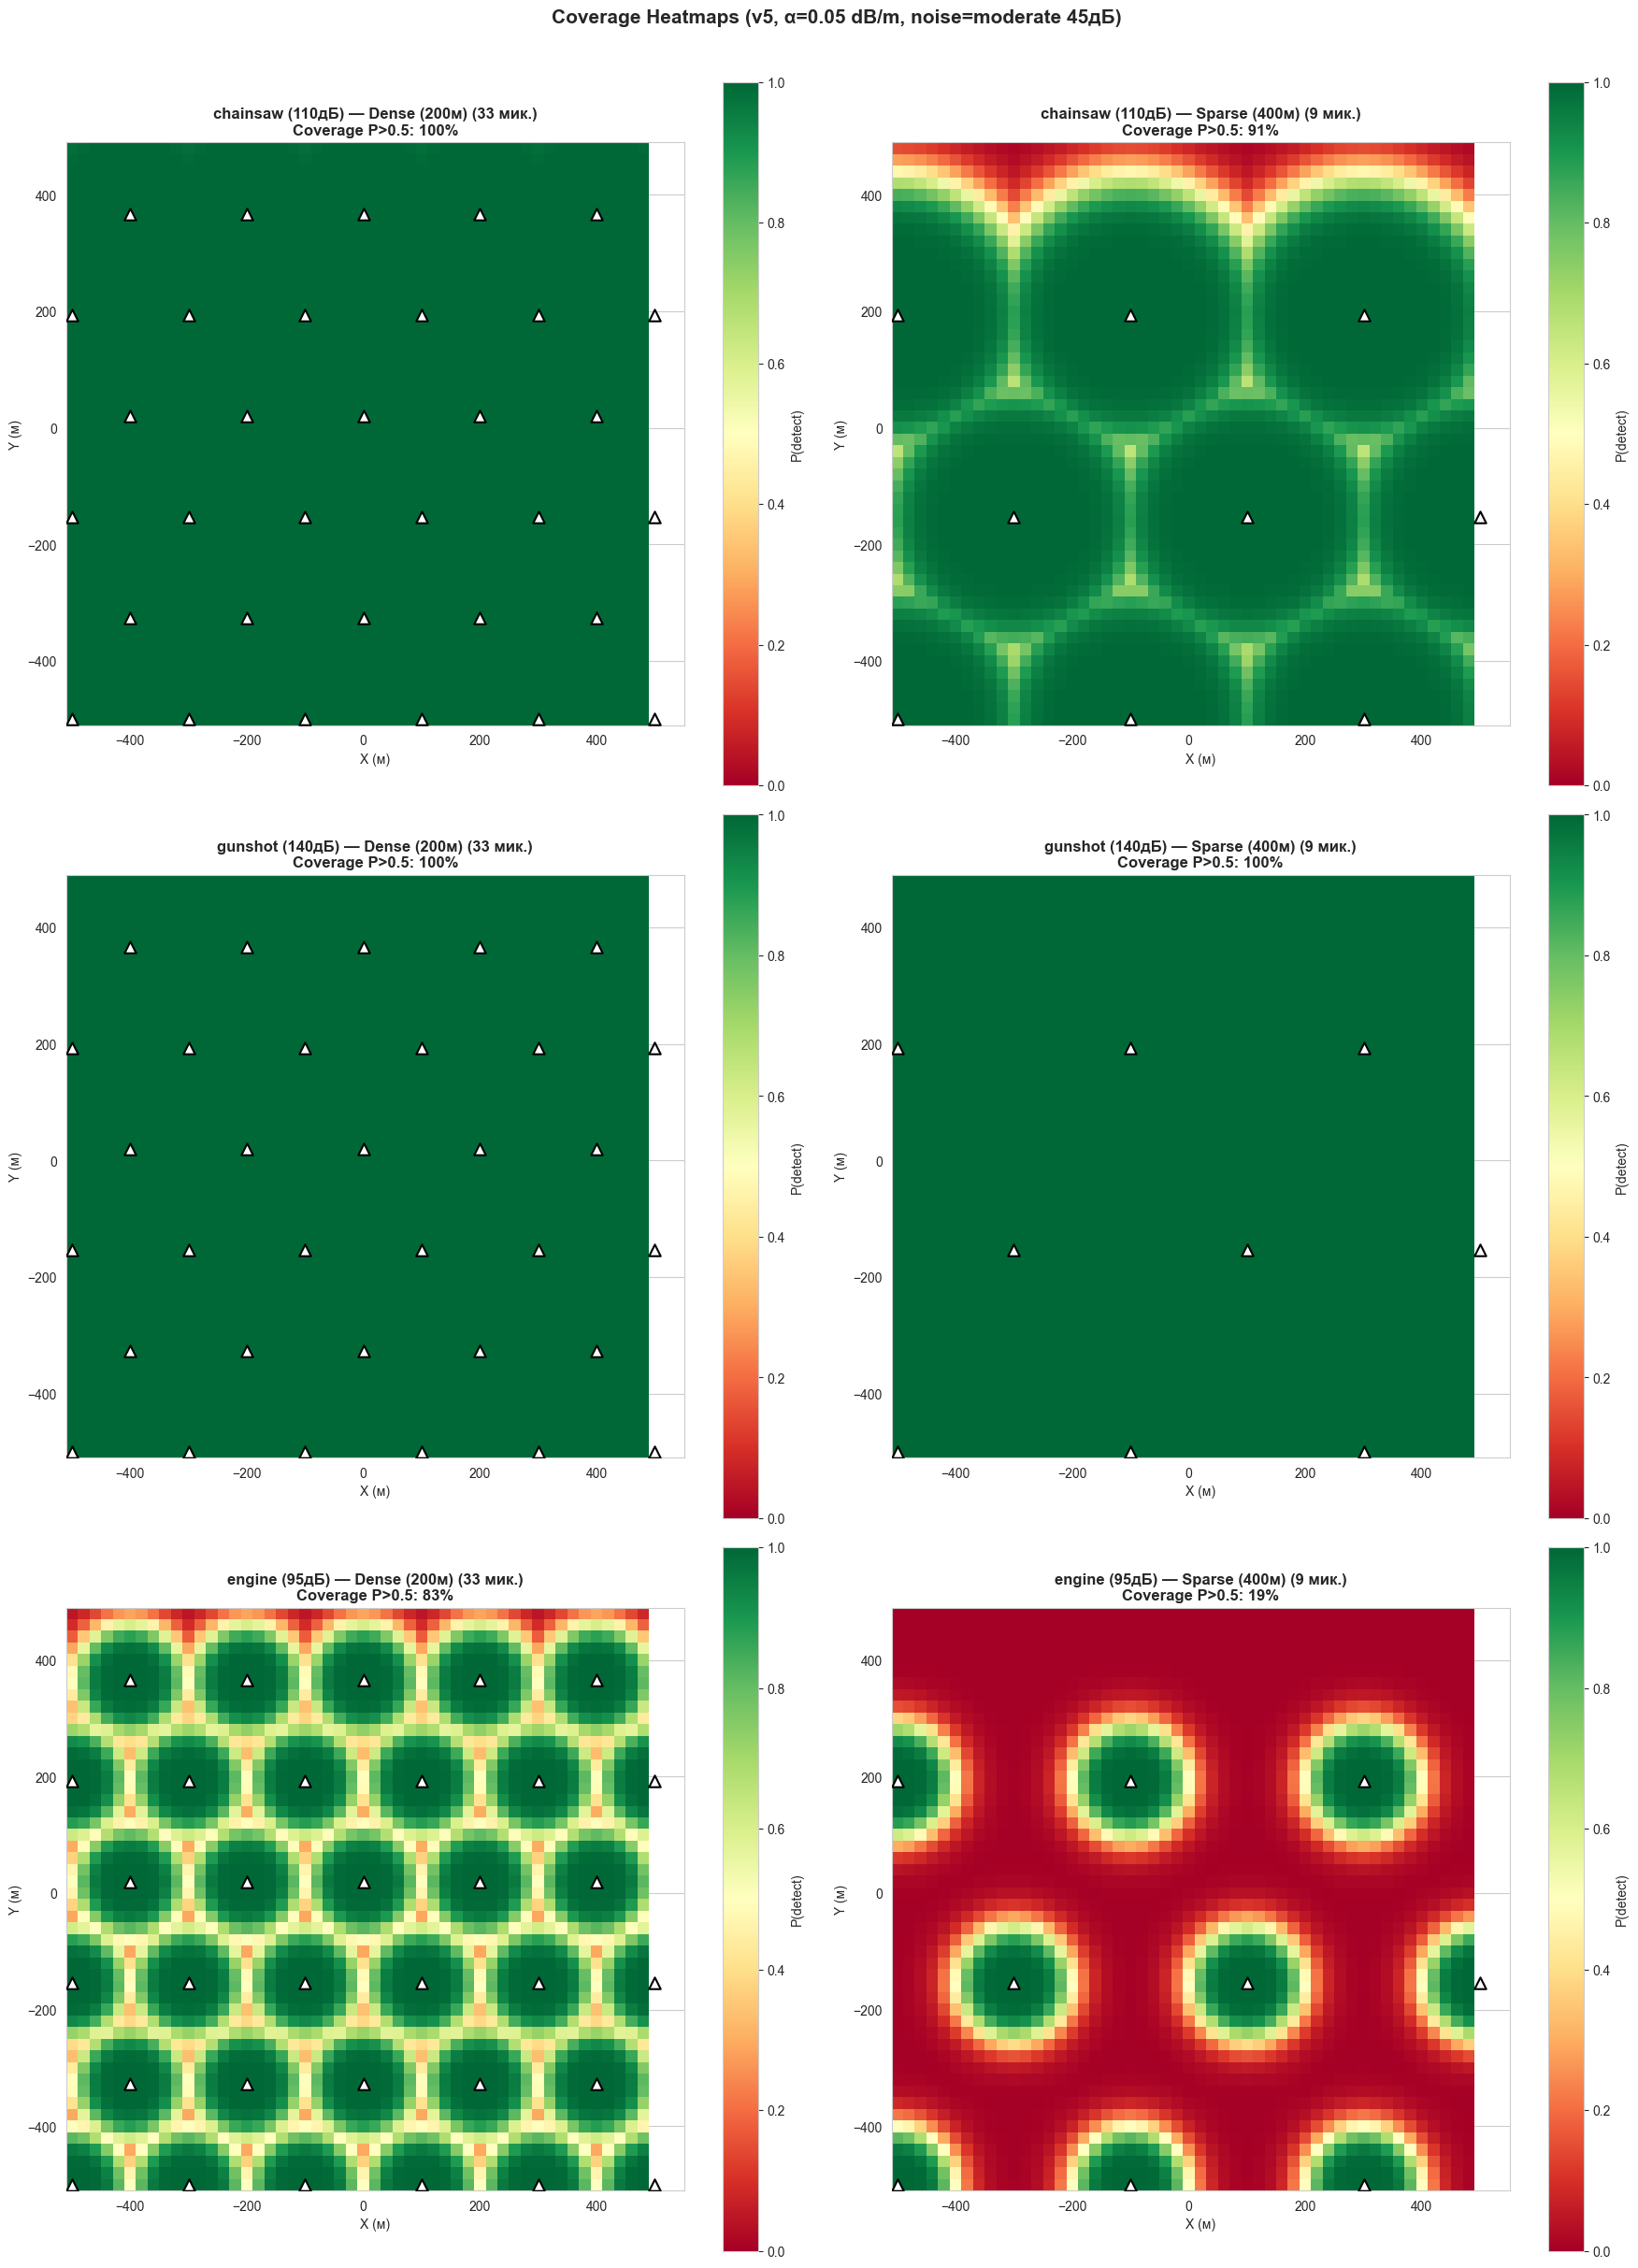

ПОКРЫТИЕ ПО ЦЕЛЯМ И ПЛОТНОСТИ СЕТКИ (P>0.5)
Target       SPL      Dense 200м      Sparse 400м    
--------------------------------------------------
chainsaw     110      100%            91%            
gunshot      140      100%            100%           
engine       95       83%             19%            

Для презентации: α=0.05 dB/m, шум=45дБ, порог SNR=5дБ


In [15]:
# Multi-target coverage heatmaps (v5: chainsaw, gunshot, engine)
COVERAGE_TARGETS = ['chainsaw', 'gunshot', 'engine']
COVERAGE_SPACINGS = [('Dense (200м)', 200), ('Sparse (400м)', 400)]

fig, axes = plt.subplots(len(COVERAGE_TARGETS), len(COVERAGE_SPACINGS),
                         figsize=(18, 8 * len(COVERAGE_TARGETS)))

for row, target in enumerate(COVERAGE_TARGETS):
    for col, (label, spacing) in enumerate(COVERAGE_SPACINGS):
        ax = axes[row, col]
        mics = hex_grid(1000, spacing)
        X, Y, P = coverage_heatmap(mics, target, 'moderate')

        im = ax.pcolormesh(X, Y, P, cmap='RdYlGn', vmin=0, vmax=1, shading='auto')
        ax.scatter(mics[:, 0], mics[:, 1], marker='^', c='white',
                   edgecolors='black', s=80, linewidth=1.5, zorder=5)
        plt.colorbar(im, ax=ax, label='P(detect)')

        coverage_pct = np.mean(P > 0.5) * 100
        ax.set_title(f'{target} ({SOURCE_SPL[target]}дБ) — {label} ({len(mics)} мик.)\n'
                     f'Coverage P>0.5: {coverage_pct:.0f}%',
                     fontsize=12, fontweight='bold')
        ax.set_xlabel('X (м)')
        ax.set_ylabel('Y (м)')
        ax.set_aspect('equal')

plt.suptitle(f'Coverage Heatmaps (v5, α={DEFAULT_EXCESS_ATTEN} dB/m, noise=moderate {NOISE_SPL["moderate"]}дБ)',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'coverage_heatmap_v5.png', dpi=150, bbox_inches='tight')
plt.show()

# Coverage summary table
print('ПОКРЫТИЕ ПО ЦЕЛЯМ И ПЛОТНОСТИ СЕТКИ (P>0.5)')
print('=' * 70)
print(f'{"Target":<12} {"SPL":<8} {"Dense 200м":<15} {"Sparse 400м":<15}')
print('-' * 50)

for target in COVERAGE_TARGETS:
    coverages = []
    for _, spacing in COVERAGE_SPACINGS:
        mics = hex_grid(1000, spacing)
        _, _, P = coverage_heatmap(mics, target, 'moderate')
        coverages.append(f'{np.mean(P > 0.5) * 100:.0f}%')
    print(f'{target:<12} {SOURCE_SPL[target]:<8} {coverages[0]:<15} {coverages[1]:<15}')

print(f'\nДля презентации: α={DEFAULT_EXCESS_ATTEN} dB/m, шум={NOISE_SPL["moderate"]}дБ, порог SNR={SNR_THRESHOLD}дБ')

## Секция 8 — Мультимикрофонный массив (beamforming)

SNR gain = 10·log10(N) дБ при суммировании N некоррелированных каналов.

> **v4 footnote (Fix 8):** Показан теоретический потолок delay-and-sum beamforming.
> Реальный gain составляет 60-80% от теории из-за ошибок steering delay,
> несовпадения характеристик микрофонов и пространственного aliasing.

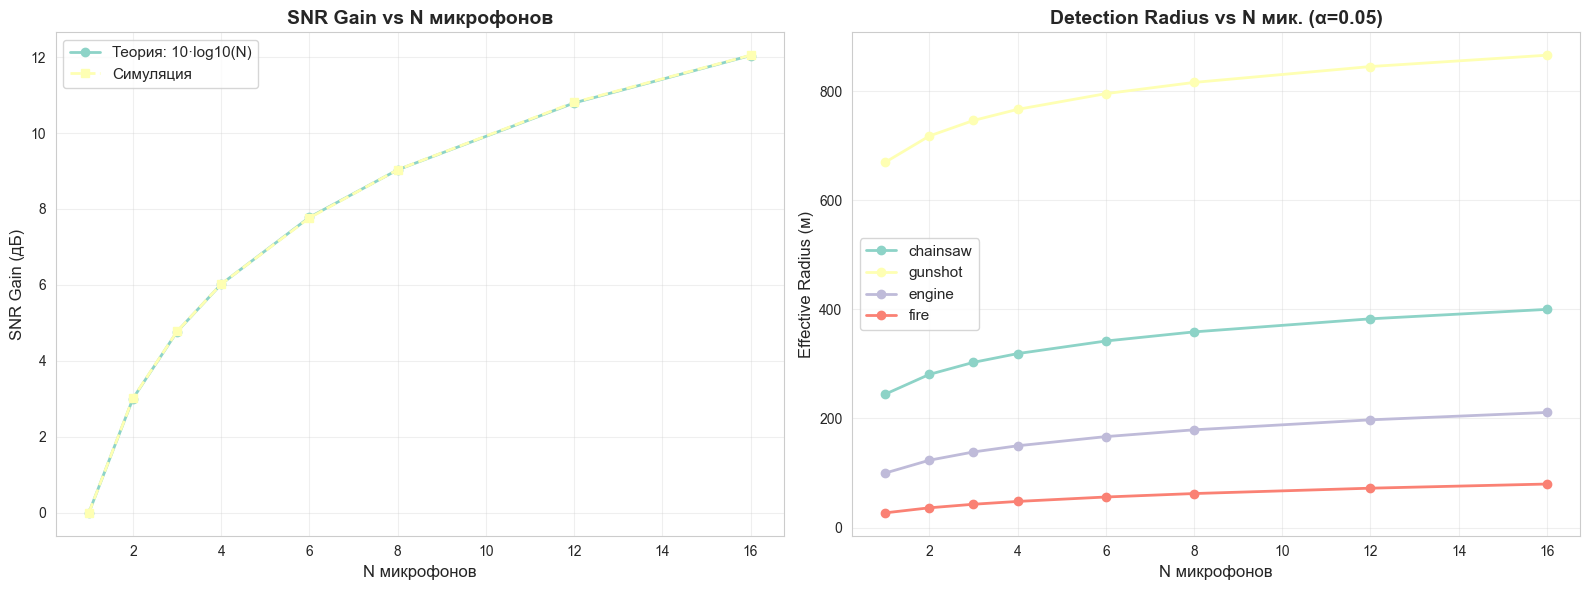

Beamforming: α=0.05 dB/m (unified with all sections)


In [16]:
def simulate_beamforming_gain(signal, noise, n_mics_list, n_trials=20):
    rng = np.random.RandomState(42)
    results = {}

    sig_len = min(len(signal), len(noise))
    signal = signal[:sig_len]
    noise = noise[:sig_len]

    rms_signal = np.sqrt(np.mean(signal**2))

    for n_mics in n_mics_list:
        gains = []
        for _ in range(n_trials):
            summed_signal = np.zeros(sig_len)
            summed_noise = np.zeros(sig_len)
            for m in range(n_mics):
                summed_signal += signal
                phase_shift = rng.randint(0, sig_len)
                shifted_noise = np.roll(noise, phase_shift)
                summed_noise += shifted_noise

            rms_s = np.sqrt(np.mean(summed_signal**2))
            rms_n = np.sqrt(np.mean(summed_noise**2))
            snr_combined = 20 * np.log10(rms_s / rms_n) if rms_n > 0 else 0

            rms_n_single = np.sqrt(np.mean(noise**2))
            snr_single = 20 * np.log10(rms_signal / rms_n_single) if rms_n_single > 0 else 0

            gains.append(snr_combined - snr_single)

        results[n_mics] = np.mean(gains)

    return results


def effective_radius(source_spl, noise_spl, threshold_snr, n_mics=1,
                     excess_atten=DEFAULT_EXCESS_ATTEN):
    """v5: uses DEFAULT_EXCESS_ATTEN=0.05 (was 0.1)."""
    gain = 10 * np.log10(n_mics)
    lo, hi = 1.0, 10000.0
    for _ in range(50):
        mid = (lo + hi) / 2
        snr = compute_snr_at_distance(source_spl, noise_spl, mid, excess_atten) + gain
        if snr > threshold_snr:
            lo = mid
        else:
            hi = mid
    return (lo + hi) / 2


n_mics_list = [1, 2, 3, 4, 6, 8, 12, 16]

test_sig = target_samples['chainsaw'][0][:TARGET_SR*3]
test_noise = list(bg_audio.values())[0][:TARGET_SR*3]
sim_gains = simulate_beamforming_gain(test_sig, test_noise, n_mics_list)
theory_gains = {n: 10*np.log10(n) for n in n_mics_list}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
ax.plot(n_mics_list, [theory_gains[n] for n in n_mics_list],
        'o-', label='Теория: 10·log10(N)', linewidth=2)
ax.plot(n_mics_list, [sim_gains[n] for n in n_mics_list],
        's--', label='Симуляция', linewidth=2)
ax.set_xlabel('N микрофонов', fontsize=12)
ax.set_ylabel('SNR Gain (дБ)', fontsize=12)
ax.set_title('SNR Gain vs N микрофонов', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

ax = axes[1]
noise_spl_cov = NOISE_SPL['moderate']
for target in ['chainsaw', 'gunshot', 'engine', 'fire']:
    radii = [effective_radius(SOURCE_SPL[target], noise_spl_cov, SNR_THRESHOLD, n) for n in n_mics_list]
    ax.plot(n_mics_list, radii, 'o-', linewidth=2, label=target)

ax.set_xlabel('N микрофонов', fontsize=12)
ax.set_ylabel('Effective Radius (м)', fontsize=12)
ax.set_title(f'Detection Radius vs N мик. (α={DEFAULT_EXCESS_ATTEN})', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'beamforming_effect_v5.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Beamforming: α={DEFAULT_EXCESS_ATTEN} dB/m (unified with all sections)')

## Итоги (v5)

In [17]:
print('=' * 70)
print('ИТОГИ НОУТБУКА 03 (v5)')
print('=' * 70)

print('\n1. ДАЛЬНОСТЬ ДЕТЕКЦИИ (forest, alpha=0.05):')
for target in ALL_TARGETS:
    if target not in target_samples:
        continue
    sub = dist_df[(dist_df['target_class'] == target) & (dist_df['atten_model'] == 'forest')]
    for d in sorted(sub['distance_m'].unique()):
        score = sub[sub['distance_m'] == d]['target_score_family'].mean()
        snr = sub[sub['distance_m'] == d]['snr_db'].mean()
        if score < 0.05:
            print(f'  {target}: effective radius ~{d}m (score<0.05, SNR={snr:.0f} dB)')
            break
    else:
        max_d = sub['distance_m'].max()
        print(f'  {target}: detected up to {max_d}m+')

print(f'\n2. TDOA ТРИАНГУЛЯЦИЯ (v5 — 10 improvements):')
print(f'  Массив: {MIC_SPACING}м треугольник, {N_EVENTS} событий x 3 сигнала x 3 зоны x 2 фона')
print(f'  Методы по типу сигнала:')
for sig, method in SIGNAL_TDOA_METHOD.items():
    bp = SIGNAL_BANDPASS.get(sig)
    beta = SIGNAL_BETA.get(sig)
    print(f'    {sig}: {method} (bandpass={bp}, beta={beta})')

print(f'\n  v5 improvements:')
print(f'    0.1: GCC-PHAT abs() bug fix')
print(f'    0.2: Bandpass 1000-3000 Hz (was 500-4000 Hz — regression)')
print(f'    0.3: amplitude_localize uses real measured SNR')
print(f'    3.1: Subpixel interpolation')
print(f'    3.2: PHAT-beta=0.75 for forest reverb')
print(f'    3.3: Median GCC accumulation (30 frames)')
print(f'    3.4: MAD outlier rejection')
print(f'    3.5: Early-peak selection')
print(f'    3.6: DEMON for engine')
print(f'    3.7: Spectral subtraction for rain')

for sig_name in TDOA_SIGNALS:
    sub = tdoa_df[tdoa_df['signal'] == sig_name]
    inside = sub[sub['zone'] == 'inside']
    method = SIGNAL_TDOA_METHOD[sig_name]
    print(f'\n  {sig_name} ({method}):')
    print(f'    Overall: median={sub["error_m"].median():.1f}m, '
          f'mean={sub["error_m"].mean():.1f}m, P95={sub["error_m"].quantile(0.95):.1f}m')
    print(f'    Inside:  median={inside["error_m"].median():.1f}m, '
          f'mean={inside["error_m"].mean():.1f}m')
    # По background
    for bg_label in TDOA_BACKGROUNDS:
        sub_bg = inside[inside['background'] == bg_label]
        if len(sub_bg) > 0:
            print(f'      {bg_label}: median={sub_bg["error_m"].median():.1f}m')

print(f'\n3. AMPLITUDE LOCALIZATION — Engine (v5 Fix 0.3):')
print(f'  Engine DEMON median:    {tdoa_df[tdoa_df["signal"]=="engine"]["error_m"].median():.1f}m')
print(f'  Engine amplitude median:{amp_df["error_m"].median():.1f}m')

print(f'\n4. ПОКРЫТИЕ (alpha={DEFAULT_EXCESS_ATTEN}, noise=moderate):')
for label, spacing in [('Dense 200m', 200), ('Sparse 400m', 400)]:
    mics = hex_grid(1000, spacing)
    print(f'  {label}: {len(mics)} mics/km2')

print(f'\n5. BEAMFORMING (alpha={DEFAULT_EXCESS_ATTEN}):')
for n in [1, 4, 8, 16]:
    r = effective_radius(SOURCE_SPL['chainsaw'], NOISE_SPL['moderate'], SNR_THRESHOLD, n)
    print(f'  N={n}: chainsaw radius = {r:.0f}m')

print(f'\n6. СРАВНЕНИЕ v4 -> v5:')
print(f'  | Метрика                    | v4               | v5                     |')
print(f'  |----------------------------|------------------|------------------------|')
cs_quiet = tdoa_df[(tdoa_df['signal']=='chainsaw') & (tdoa_df['background']=='quiet') & (tdoa_df['zone']=='inside')]
cs_rain = tdoa_df[(tdoa_df['signal']=='chainsaw') & (tdoa_df['background']=='noisy') & (tdoa_df['zone']=='inside')]
gs_quiet = tdoa_df[(tdoa_df['signal']=='gunshot') & (tdoa_df['background']=='quiet') & (tdoa_df['zone']=='inside')]
eng_all = tdoa_df[tdoa_df['signal']=='engine']
print(f'  | Chainsaw TDOA quiet inside | 4.2m             | {cs_quiet["error_m"].median():.1f}m (subpixel+beta) |')
print(f'  | Chainsaw TDOA rain inside  | 105m (regression)| {cs_rain["error_m"].median():.1f}m (medianGCC+SS)  |')
print(f'  | Gunshot TDOA quiet inside  | 0.5m             | {gs_quiet["error_m"].median():.1f}m (subpixel)     |')
print(f'  | Engine TDOA (all)          | TDOA broken      | {eng_all["error_m"].median():.1f}m (DEMON)        |')
print(f'  | Engine amplitude           | 79.8m            | {amp_df["error_m"].median():.1f}m (real SNR fix)  |')

print('\nНоутбук 03 v5 завершён.')

ИТОГИ НОУТБУКА 03 (v5)

1. ДАЛЬНОСТЬ ДЕТЕКЦИИ (forest, alpha=0.05):
  chainsaw: detected up to 1000m+
  gunshot: detected up to 1000m+
  engine: detected up to 1000m+
  axe: effective radius ~200m (score<0.05, SNR=-16 dB)
  fire: effective radius ~200m (score<0.05, SNR=-21 dB)

2. TDOA ТРИАНГУЛЯЦИЯ (v5 — 10 improvements):
  Массив: 200м треугольник, 50 событий x 3 сигнала x 3 зоны x 2 фона
  Методы по типу сигнала:
    gunshot: gcc_phat (bandpass=None, beta=1.0)
    chainsaw: median_gcc (bandpass=(1000, 3000), beta=0.75)
    engine: demon (bandpass=None, beta=0.75)

  v5 improvements:
    0.1: GCC-PHAT abs() bug fix
    0.2: Bandpass 1000-3000 Hz (was 500-4000 Hz — regression)
    0.3: amplitude_localize uses real measured SNR
    3.1: Subpixel interpolation
    3.2: PHAT-beta=0.75 for forest reverb
    3.3: Median GCC accumulation (30 frames)
    3.4: MAD outlier rejection
    3.5: Early-peak selection
    3.6: DEMON for engine
    3.7: Spectral subtraction for rain

  gunshot (gcc_ph

In [ ]:
import tensorflow as tf
import numpy as np

# Rebuild architecture (Keras 2 compatible)
model = tf.keras.Sequential([
  tf.keras.layers.Dense(256, input_shape=(2048,)),
  tf.keras.layers.BatchNormalization(),
  tf.keras.layers.Activation("relu"),
  tf.keras.layers.Dropout(0.3),
  tf.keras.layers.Dense(128),
  tf.keras.layers.BatchNormalization(),
  tf.keras.layers.Activation("relu"),
  tf.keras.layers.Dropout(0.3),
  tf.keras.layers.Dense(6, activation="softmax"),
])

# Load trained weights
w = np.load("yamnet_v7_weights.npz")
model.layers[0].set_weights([w["layer0_w0"], w["layer0_w1"]])
model.layers[1].set_weights([w["layer1_w0"], w["layer1_w1"], w["layer1_w2"], w["layer1_w3"]])
model.layers[4].set_weights([w["layer4_w0"], w["layer4_w1"]])
model.layers[5].set_weights([w["layer5_w0"], w["layer5_w1"], w["layer5_w2"], w["layer5_w3"]])
model.layers[8].set_weights([w["layer8_w0"], w["layer8_w1"]])

print(f"Model loaded: {model.input_shape} -> {model.output_shape}")
print(f"Parameters: {model.count_params():,}")

CLASSES = ["chainsaw", "gunshot", "engine", "axe", "fire", "background"]

test_input = np.random.randn(1, 2048).astype(np.float32)
predictions = model.predict(test_input)
predicted_class = CLASSES[np.argmax(predictions)]
confidence = float(np.max(predictions))
print(f"Predicted: {predicted_class} ({confidence:.1%})")